<a href="https://colab.research.google.com/github/MInesGomes/DataScienceObesityLevels/blob/main/DSGroup2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<a id='toc'>


# TABLE OF CONTENTS
</a>

- [0. Identify Business needs](#business)
- [1. Import Data](#import)
- [2. Explore Data](#explore)
  - [2.1. Basic Exploration](#basic)
  - [2.2. Statistical Exploration & encoding](#stats)
    - [2.2.1. Numerical Variables](#stats_num)
    - [2.2.2. Categorical Variables (Binary)](#stats_cat)
    - [2.2.3. Ordinal Encoding](#stats_ord)
    - [2.3.4. Create Dummy variables for Means of Transportation](#dummy)
  - [2.3. Visual Exploration](#visual)
- [3. Data Preprocess](#preprocess)
  - [3.1. Skewness and kurtosis](#skew)
  - [3.2 Outlier Detection and Removal](#outlier_detection)
  - [3.3. Create new variables](#new)
  - [3.4. Scaling](#scale)
- [4. In-depth Exploration](#depth)
  - [4.1. Do physical activity levels significantly influence obesity classification?](#inDepht_1)
  - [4.2. Are eating habits stronger predictors of obesity than demographic factors?](#inDepht_2)
  - [4.3. Is there a relationship between technology usage (screen time) and obesity levels?](#inDepht_3)
  - [4.4. Do transportation habits correlate with healthier lifestyles?](#inDepht_4)
  - [4.5. Can obesity patterns vary across age groups and genders?](#inDepht_5)
- [5. Predictive Modeling](#predictive_modeling)
  - [5.1 Logistic Regression](#clean)
  - [5.2 Random Forest to confirm the most important predictors](#clean)
  - [5.3 Decision Trees - IN PROGRESS (Annamaria)](#clean)
  - [5.4 Support Vector Machine (SVM) model](#clean)
  - [5.5 K-Nearest Neighbors](#clean)
  - [5.6 Gradient Boosting methods](#clean)
- [6. Explainable AI](#explain)


# **0. Identify Business needs**

<a id='business'> </a>


Obesity is one of the most significant global public health challenges of the 21st century. According to the World Health Organization (WHO), it is a primary driver of cardiovascular diseases, type 2 diabetes, and reduced life expectancy. Understanding the behavioral, dietary, and physical factors associated with obesity is critical for designing effective public health policies and personal interventions.
With the increasing availability of lifestyle data, machine learning offers powerful tools to identify complex patterns between daily habits and body mass. By analyzing eating behaviors, physical activity, technology use, and demographics, we can develop data-driven models that uncover meaningful insights into obesity risk factors.

 **Project Objectives**

The primary goal is to understand the relationship between lifestyle behaviors and obesity levels through data exploration and predictive modeling.

*   **Exploratory Analysis:** Identify behavioral patterns and correlations within the dataset.
*   **Predictive Modeling:** Develop and evaluate classification models to predict obesity levels based on lifestyle variables.
*   **Feature Importance:** Determine which habits (e.g., physical activity vs. diet) are the strongest predictors of obesity risk.
*   **Actionable Insights:** Propose recommendations for public health policies and lifestyle interventions.

 **Research Questions**

*   Does physical activity significantly influence obesity classification?
*   Are eating habits stronger predictors of obesity than demographic factors?
*   Is there a measurable relationship between technology usage (screen time) and obesity levels?
*   Do transportation habits (e.g., walking vs. driving) correlate with healthier outcomes?
*   How do obesity patterns vary across different age groups and genders?

 **Dataset Limitations & Future Scope**

While this dataset provides a strong foundation, several critical factors—particularly those related to mental health and socio-economics—are currently unavailable. Future research would benefit from including:

*   **Social Context:** Eating alone vs. with family; screen time allowed during meals.
*   **Home Environment:** Single-parent households or household size.
*   **Work-Life Balance:** Long commute times leading to "cooking fatigue" and reliance on convenience foods.
*   **Dietary Specifics:** Granular data on fast food frequency and meat consumption.
*   **Geographic Diversity:** Data from a wider variety of regions and cultures.

**Project Repository:** [GitHub - Data Science Obesity Levels](https://github.com/MInesGomes/DataScienceObesityLevels)


# **1. Import Data**
<a id='import'>
</a>

**Importing dataset from github repository**
https://raw.githubusercontent.com/MInesGomes/DataScienceObesityLevels/main/ObesityDataSet_raw_and_data_sinthetic.csv
    




In [94]:
!pip install pandas numpy matplotlib seaborn scikit-learn imblearn

In [95]:
import pandas as pd
import numpy as np

# Df = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')
githubUrl = 'https://raw.githubusercontent.com/MInesGomes/DataScienceObesityLevels/main/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(githubUrl)

print("\nDataset info:")
print(df.info())
print("\nFirst 5 rows of the dataset:")
display(df.head())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



<a id='explore'>

    
# **2. Explore Data**
</a>

**Exploring Dataset, identifying possible problems and errors, identifying outliers and getting major insights**
    
[](#toc)    



<div class="alert alert-block alert-warning">

<a id='basic'></a>

## 2.1. Basic Exploration
    


 The dataset contains 2111 entries and 17 columns. (8 numeric, 9 categorical)

 There are no missing values in any of the columns, as indicated by the 'Non-Null Count'.

 Is also difficult to find duplicates due to inexistence of person unique identifier.

**Columns datatypes (and name changes for clear understanding ):**
* **Numeric:**
  * Age
  * Height
  * Weigh
  * FreVeg (FCVC) - Frequency of vegetable consumption during meals
  * NumMeals (NCP) - Number of main meals consumed daily
  * WaterCons (CH2O) - Amount of water consumed daily
  * FrePhyAc (FAF) - Frequency of physical activity
  * TimeUseTech (TUE) - Time spent using technological devices (e.g., smartphone, computer, television, videogames)
   
* **Categorical binary  (We'l set value 1 if)**:
  * Gender -  Male
  * FamHist -   has a family history with overweight
  * FreHighCal (FAVC) -  the individual frequently consumes high-calorie food
  * Smoke (SMOKE) - the individual smokes
  * MonitorDailyCal (SCC) - the individual monitors daily calorie intake

* **Categorical:**
  * Ordinal
    * FreBetweenMeals (CAEC) - Frequency of food consumption between meals
    * FreAlcCons (CALC) - Frequency of alcohol consumption
  * Nominal
    * MTransp (MTRANS) - Primary mode of transportation used
* **Categorical ordinal**:  TargetObesityL (NObeyesdad )



In [96]:
# Renaming the columns for clear understanding
RenameMap = {
  'FCVC': 'FreVeg',
  'NCP': 'NumMeals',
  'CH2O': 'WaterCons',
  'FAF': 'FrePhyAc',
  'TUE': 'TimeUseTech',
  'family_history_with_overweight': 'FamHist',
  'FAVC': 'FreHighCal',
  'SMOKE': 'Smoke',
  'SCC': 'MonitorDailyCal',
  'CAEC': 'FreBetweenMeals',
  'CALC': 'FreAlcCons',
  'MTRANS': 'MTransp',
  'NObeyesdad': 'TargetObesityL'
}
display(df.columns)
df = df.rename(columns=RenameMap)

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [97]:
# Creating a dictionary of the variables to plot the description
VariableDescription = dict( [
    ("FreVeg", "Frequency of vegetable consumption during meals"),
    ("NumMeals", "Number of main meals consumed daily"),
    ("WaterCons", "Amount of water consumed daily"),
    ("FrePhyAc", "Frequency of physical activity"),
    ("TimeUseTech", "Time spent using technological devices"),
    ("FamHist", "has a family history with overweight"),
    ("FreHighCal", "the individual frequently consumes high-calorie food"),
    ("Smoke", "the individual smokes"),
    ("MonitorDailyCal", "the individual monitors daily calorie intake"),
    ("FreBetweenMeals", "Frequency of food consumption between meals"),
    ("FreAlcCons", "Frequency of alcohol consumption"),
    ("MTransp", "Primary mode of transportation used")
])

print(VariableDescription)

{'FreVeg': 'Frequency of vegetable consumption during meals', 'NumMeals': 'Number of main meals consumed daily', 'WaterCons': 'Amount of water consumed daily', 'FrePhyAc': 'Frequency of physical activity', 'TimeUseTech': 'Time spent using technological devices', 'FamHist': 'has a family history with overweight', 'FreHighCal': 'the individual frequently consumes high-calorie food', 'Smoke': 'the individual smokes', 'MonitorDailyCal': 'the individual monitors daily calorie intake', 'FreBetweenMeals': 'Frequency of food consumption between meals', 'FreAlcCons': 'Frequency of alcohol consumption', 'MTransp': 'Primary mode of transportation used'}


<div class="alert alert-block alert-warning">

<a id='stats'></a>

## 2.2. Statistical Exploration & encoding
    


<div class="alert alert-block alert-info">

<a id='stats_num'></a>
### 2.2.1. Numerical Variables


**Dataset: dfNumVar**

In [98]:
print("\n Describe numerical variables")
dfNumVar=df.describe().T
display(dfNumVar)


 Describe numerical variables


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FreVeg,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NumMeals,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
WaterCons,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FrePhyAc,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TimeUseTech,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


From the above table, we can get these conclusions:
- `count`- All variable have 2111 values. So no missing values.
- `weight`
  - `mean`- The mean weight is 86.58kg.
  - `50%`- Half of the population analysed has 83kg
  - `max`- And the max is 173kg. (Not sure if this value is an outlier.)
- `min`- The minimum time of technology used is 0. Not sure if it's valid.
- `max`- The age group is between 14 and 61 years old.


<div class="alert alert-block alert-info">
    
<a id='stats_cat'></a>

### 2.2.2. Categorical Variables (Binary)
Encode binary variables change object to int with (0 and 1 values)


**Dataset: dfCat**

In [99]:
print("\n Describe categorical variables")
df.describe(include = ['O'])


 Describe categorical variables


,Gender,FamHist,FreHighCal,FreBetweenMeals,Smoke,MonitorDailyCal,FreAlcCons,MTransp,TargetObesityL
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


Should we drop these variables? TODO
- `Smoke` - Has only 44 people.
- `MonitorDailyCal` Has only 96 values.

`Public_Transportation` Has the majority of the values for mode of Transportation.

These columns have binaries types but are encoded as object: ['Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal']

**Converting from `object` to `int` datatype:** (`0` and `1` values):

In [100]:
# Initialize dfCat as a copy of df to store binary encoded columns
dfCat = df.copy()

# Encoding binary categorical columns
dfCat['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
dfCat['FamHist'] = df['FamHist'].map({'no': 0, 'yes': 1})
dfCat['FreHighCal'] = df['FreHighCal'].map({'no': 0, 'yes': 1})
dfCat['Smoke'] = df['Smoke'].map({'no': 0, 'yes': 1})
dfCat['MonitorDailyCal'] = df['MonitorDailyCal'].map({'no': 0, 'yes': 1})

# List of binary columns to convert to integer type
BinaryCols = ['Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal']

# Convert the specified binary columns to integer type in dfCat
for Col in BinaryCols:
    dfCat[Col] = dfCat[Col].astype(int)
display(dfCat.info())

print("DataFrame after encoding binary columns:")
display(dfCat.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2111 non-null   int64  
 1   Age              2111 non-null   float64
 2   Height           2111 non-null   float64
 3   Weight           2111 non-null   float64
 4   FamHist          2111 non-null   int64  
 5   FreHighCal       2111 non-null   int64  
 6   FreVeg           2111 non-null   float64
 7   NumMeals         2111 non-null   float64
 8   FreBetweenMeals  2111 non-null   object 
 9   Smoke            2111 non-null   int64  
 10  WaterCons        2111 non-null   float64
 11  MonitorDailyCal  2111 non-null   int64  
 12  FrePhyAc         2111 non-null   float64
 13  TimeUseTech      2111 non-null   float64
 14  FreAlcCons       2111 non-null   object 
 15  MTransp          2111 non-null   object 
 16  TargetObesityL   2111 non-null   object 
dtypes: float64(8),

None

DataFrame after encoding binary columns:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<div class="alert alert-block alert-info">
    
<a id='stats_ord'></a>

### 2.2.3. Ordinal Encoding
    


**Dataset: dfOrdinalEnc**

For the ordinal variables `FreBetweenMeals` and `FreAlcCons`, we'll  apply ordinal encoding to maintain the order of Frequency between meals.

The columns will be ordinally encoded intothe following numerical values:

* 'no' is encoded as 0.0
* 'Sometimes' is encoded as 1.0
* 'Frequently' is encoded as 2.0
* 'Always' is encoded as 3.0

In [103]:
from sklearn.preprocessing import OrdinalEncoder

dfOrdinalEnc = dfCat.copy()
# Define the order for 'FreBetweenMeals' and 'FreAlcCons'
FreBetweenMealsOrder = ['no', 'Sometimes', 'Frequently', 'Always']

# Initialize the OrdinalEncoder with the specified categories
EncoderFbm = OrdinalEncoder(categories=[FreBetweenMealsOrder])

# Apply ordinal encoding to the 'FreBetweenMeals' column
dfOrdinalEnc['FreBetweenMeals'] = EncoderFbm.fit_transform(dfOrdinalEnc[['FreBetweenMeals']])
dfOrdinalEnc['FreAlcCons'] = EncoderFbm.fit_transform(dfOrdinalEnc[['FreAlcCons']])

print("\nDataFrame after ordinal encoding 'FreBetweenMeals' and 'FreAlcCons':")
display(dfOrdinalEnc.head())
print("\nUnique encoded values for:")
print(dfOrdinalEnc['FreBetweenMeals'].value_counts())
print(dfOrdinalEnc['FreAlcCons'].value_counts())


DataFrame after ordinal encoding 'FreBetweenMeals' and 'FreAlcCons':


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1.0,0,2.0,0,0.0,1.0,0.0,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1.0,1,3.0,1,3.0,0.0,1.0,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1.0,0,2.0,0,2.0,1.0,2.0,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1.0,0,2.0,0,2.0,0.0,2.0,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1.0,0,2.0,0,0.0,0.0,1.0,Public_Transportation,Overweight_Level_II



Unique encoded values for:
FreBetweenMeals
1.0    1765
2.0     242
3.0      53
0.0      51
Name: count, dtype: int64
FreAlcCons
1.0    1401
0.0     639
2.0      70
3.0       1
Name: count, dtype: int64


The `value_counts()` output for the remaining categorical features (`FreBetweenMeals`, `FreAlcCons`, and `MTransp`) shows the following:

*   **`FreBetweenMeals` (Frequency of food consumption between meals):**
    *   The vast majority of individuals (`1765`) consume food **'Sometimes'** between meals.
    *   A smaller group (`242`) does so **'Frequently'**.
    *   Very few (`53`) consume food **'Always'** between meals, and an even smaller number (`51`) **'no'** food between meals.

*   **`FreAlcCons` (Frequency of alcohol consumption):**
    *   Most individuals (`1401`) consume alcohol **'Sometimes'**.
    *   A significant portion (`639`) consume **'no'** alcohol.
    *   Only a small number (`70`) consume alcohol **'Frequently'**.
    *   Only `1` individual consumes alcohol **'Always'**, which was identified as a potential **outlier earlier.**

*   **`MTransp` (Primary mode of transportation used):**
    *   The overwhelming majority (`1580`) use **'Public_Transportation'**.
    *   **'Automobile'** is the second most common mode (`457`).
    *   **'Walking'** is used by a much smaller group (`56`).
    *   **'Motorbike'** (`11`) and **'Bike'** (`7`) are very rarely used, suggesting these categories might have limited predictive power due to their low frequency.


For the target variable `TargetObesityL`, we'll also apply ordinal encoding to maintain the order of obesity levels.

**Dataset: dfTargetEnc**

In [ ]:
dfTargetEnc = dfOrdinalEnc.copy()

# Define the order of the obesity levels
ObesityOrder = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

# Initialize the OrdinalEncoder with the specified categories
Encoder = OrdinalEncoder(categories=[ObesityOrder])

# Apply ordinal encoding to the 'TargetObesityL' column
dfTargetEnc['TargetObesityL'] = Encoder.fit_transform(dfTargetEnc[['TargetObesityL']])

print("\nDataFrame after ordinal encoding 'TargetObesityL':")
display(dfTargetEnc.head())
print("\nUnique encoded values for 'TargetObesityL':")
print(dfTargetEnc['TargetObesityL'].value_counts())

<div class="alert alert-block alert-info">
    
<a id='dummy'></a>

### 2.3.4. Create Dummy variables for Means of Transportation
    


In [ ]:
dfClean = dfTargetEnc.copy()
# One-hot encoding for multi-category nominal features
NominalCols = ['MTransp']
# dfHot = pd.get_dummies(dfTransformed, columns=NominalCols, drop_first=True, dtype=int)
dfClean = pd.get_dummies(dfClean, columns=NominalCols, drop_first=False, dtype=int)

print("\nDataFrame after one-hot encoding:")
display(dfClean)

In [ ]:
dfClean.info()

<div class="alert alert-block alert-warning">

<a id='visual'></a>

## 2.3. Visual Exploration
    
    


Checking the distribution of the numeric variables using a `histplot()`. Define the color as green and the number of bins equal to 30.

**Dataset: dfClean**

#### Distribution of TargetObesityLs

In [115]:
sns.set_palette("viridis")

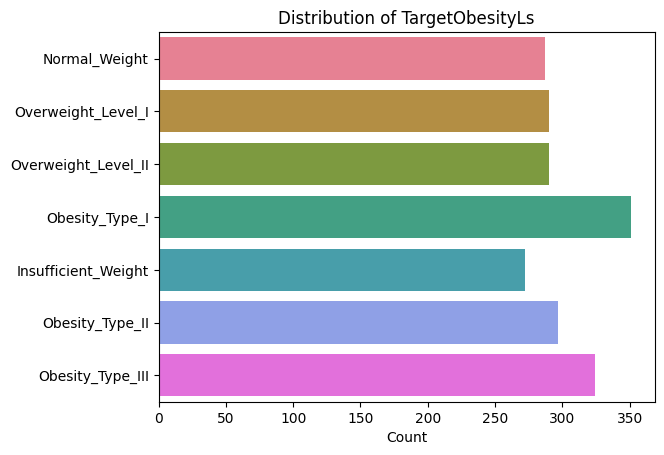

In [116]:
# Visualize the distribution of TargetObesityLs using a count plot
sns.countplot(data=dfCat, y="TargetObesityL", hue="TargetObesityL", legend=False)

# Add title and labels to the plot
plt.title("Distribution of TargetObesityLs")
plt.ylabel("")
plt.xlabel("Count")

# Display the plot
plt.show()

#### Distribution of Transportation Modes

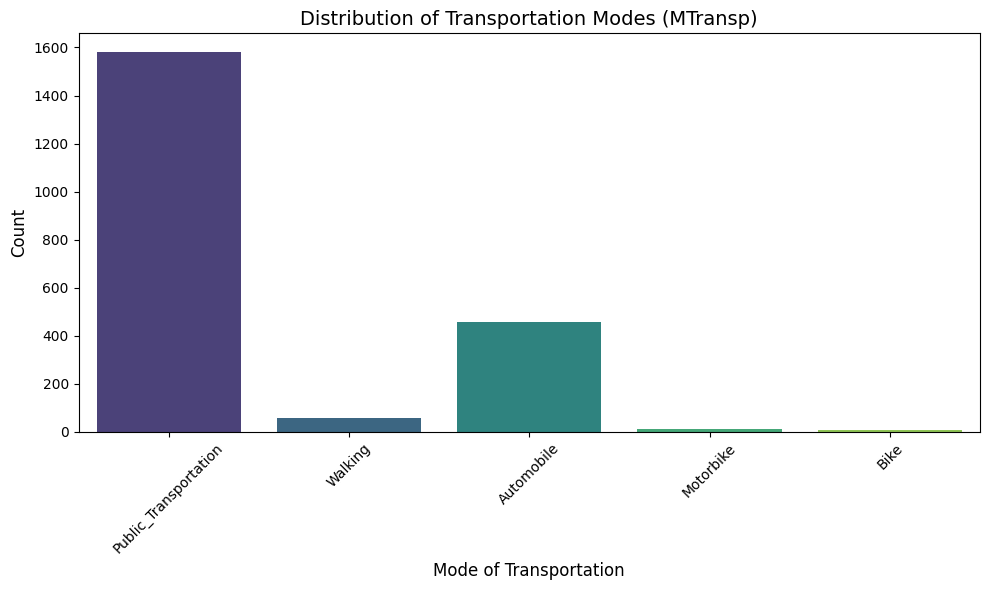

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram (countplot) for MTransp from dfCat
plt.figure(figsize=(10, 6))
sns.countplot(data=dfCat, x='MTransp', palette='viridis', hue='MTransp', legend=False)

# Adding labels and title
plt.title('Distribution of Transportation Modes (MTransp)', fontsize=14)
plt.xlabel('Mode of Transportation', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Correlation Matrix: All Features

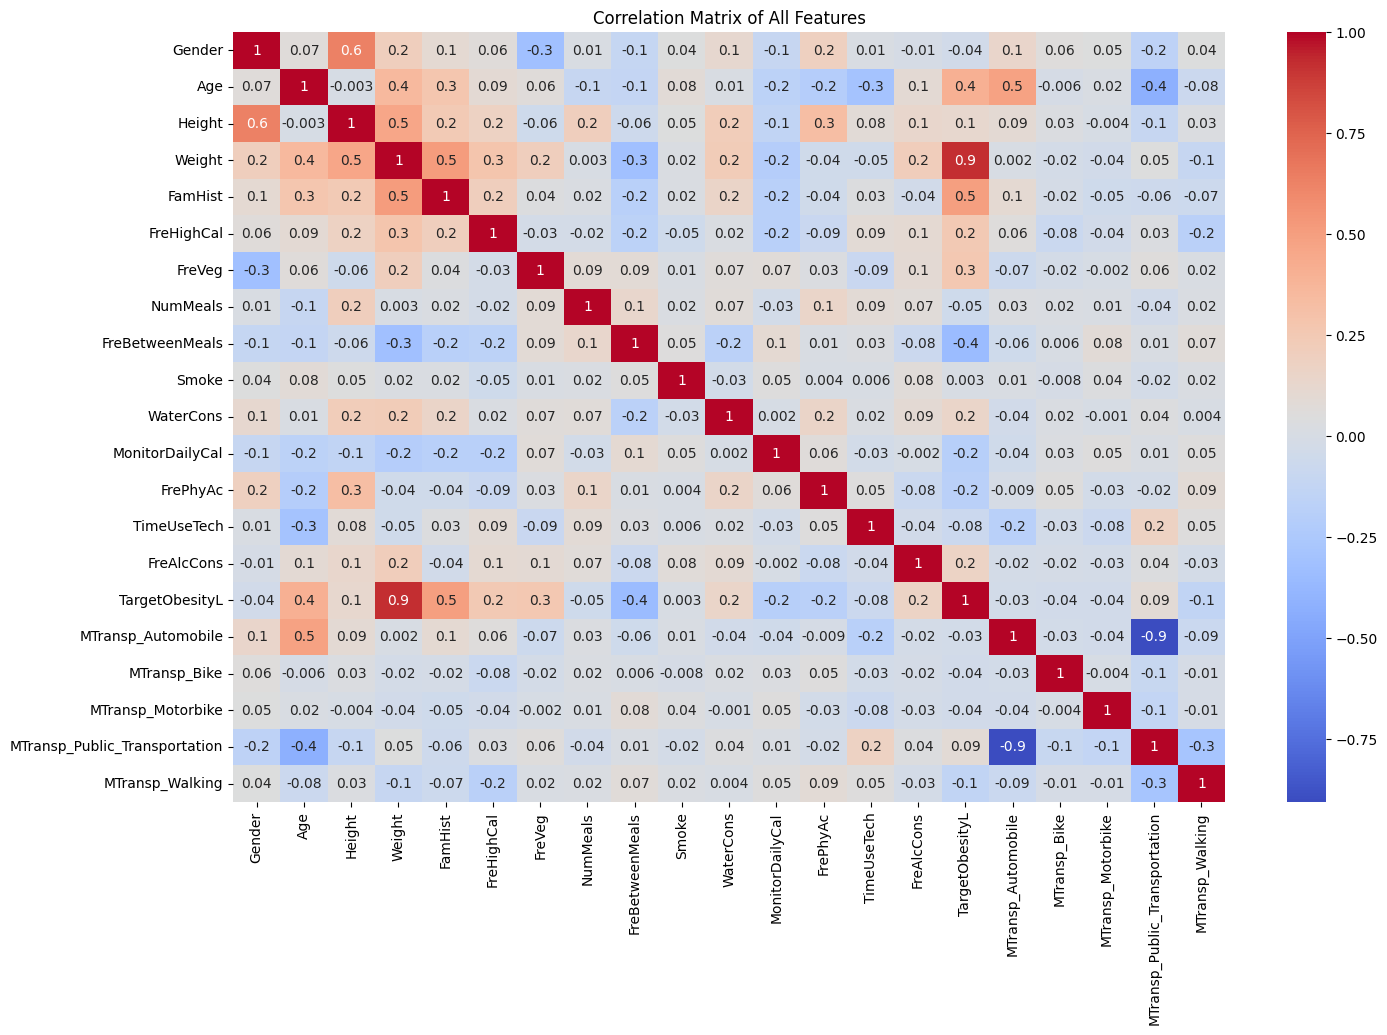

In [117]:
dfCorr = dfClean.corr(method = 'spearman', numeric_only=True)

plt.figure(figsize=(16,10))
sns.heatmap(dfCorr, annot=True, fmt = '.1g', cmap='coolwarm')
plt.title('Correlation Matrix of All Features')
plt.show()

The correlation matrix  visually represents the linear relationships between all numerical features in your dataset. Strong positive correlations are shown with warm colors (closer to red), indicating that as one variable increases, the other tends to increase. Strong negative correlations are depicted with cool colors (closer to blue), meaning as one variable increases, the other tends to decrease. Correlations near zero are typically light-colored, suggesting a weak or no linear relationship.

**Key Insights from the Correlation Matrix :**

*   **Height and Weight:** As expected, these two physical attributes show a strong positive correlation, meaning taller individuals generally weigh more.
*   **Gender:** Often correlates with Height and Weight (e.g., males generally tend to be taller and heavier).
*   **Age:** Can show moderate correlations with certain lifestyle factors or other physical attributes.
*   **Eating Habits:** Variables like `FreVeg` (Frequency of Vegetable Consumption) and `FreHighCal` (Frequency of High-Calorie food) might show negative and positive correlations, respectively, with `Weight` or other related factors.

In summary, these results collectively suggest that obesity is influenced by a complex interplay of demographic factors (Age, Height, Gender, Family History) and daily lifestyle choices, particularly eating habits and technology usage.

#### Correlation Matrix: Eating Habits

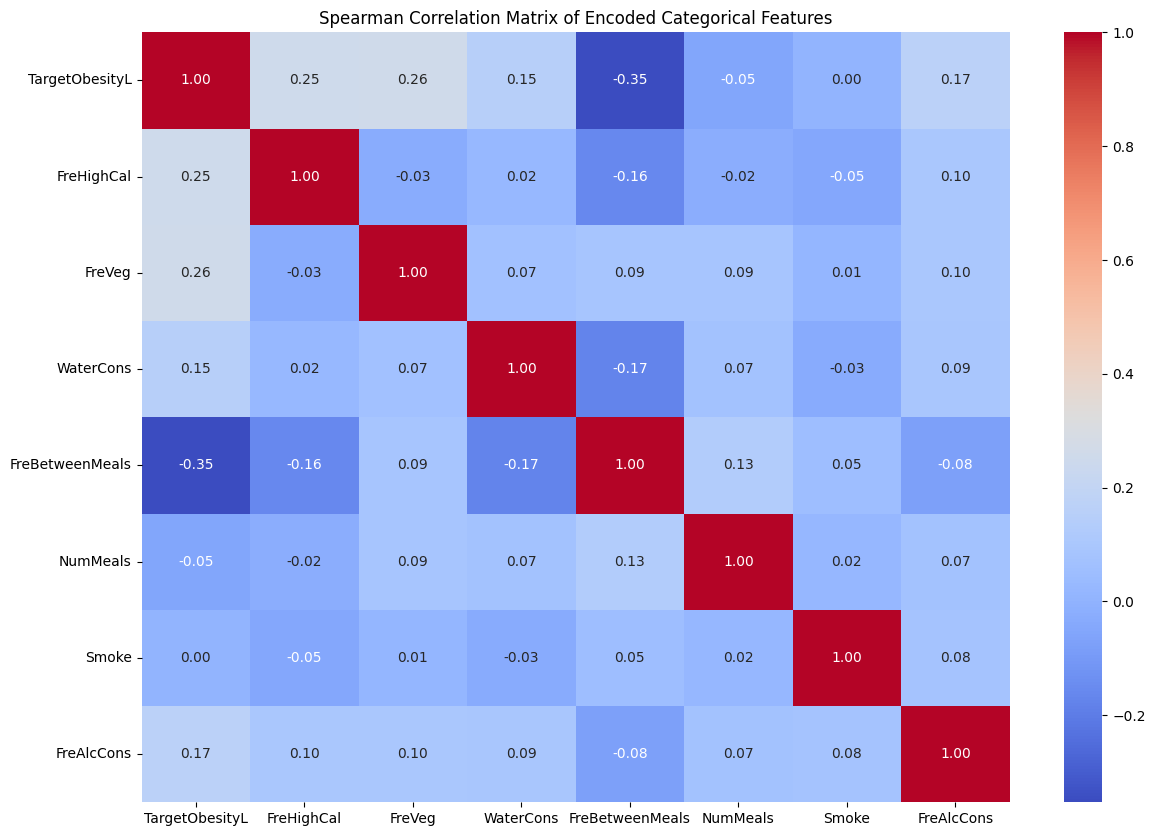

In [119]:
meals_cols = ['TargetObesityL',
    'FreHighCal', 'FreVeg', 'WaterCons',
    'FreBetweenMeals', 'NumMeals',
    'Smoke', 'FreAlcCons'
]

dfMealsEncoded = dfClean[meals_cols].copy()

dfCatCorr = dfCatEncoded.corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(dfCatCorr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Spearman Correlation Matrix of Encoded Categorical Features')
plt.show()

#### Pair Plot of 'FrePhyAc', 'TimeUseTech

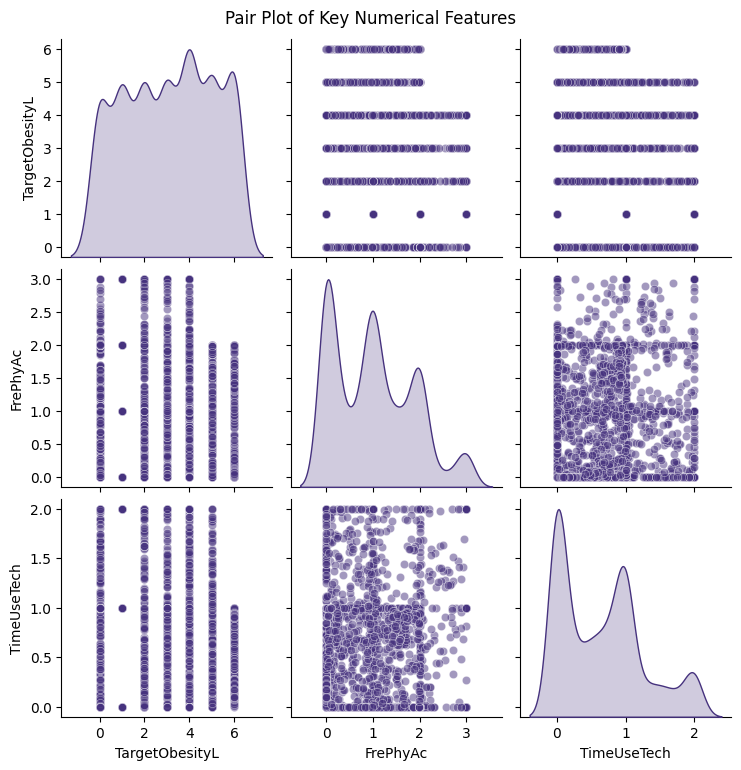

In [125]:
# Pair Plot visualization code

selec_cols = ['TargetObesityL','FrePhyAc', 'TimeUseTech']
    # 'MTransp_Automobile', 'MTransp_Bike', 'MTransp_Motorbike',
    # 'MTransp_Public_Transportation', 'MTransp_Walking'

    #  'MonitorDailyCal', TODO REMOVE

    # 'FamHist',
df_pairplot = dfClean[selec_cols].apply(pd.to_numeric, errors='coerce')
df_pairplot = df_pairplot[np.isfinite(df_pairplot).all(axis=1)]

# Generate the pairplot
sns.pairplot(df_pairplot, kind="scatter", diag_kind="kde", plot_kws={'alpha': 0.5})
plt.suptitle("Pair Plot of 'FrePhyAc', 'TimeUseTech'", y=1.02)
plt.show()



Pair plot of Obesity Level, Physical Activity (`FrePhyAc`), and Technology Usage (`TimeUseTech`), takeaways:

**Distributions (Diagonal):**
* **TargetObesityL:** Shows a relatively uniform distribution, confirming that the dataset categories are balanced.
* **Physical Activity:** Shows a spread across different levels, but with distinct peaks, likely reflecting the original survey increments.
* **Technology Usage:** Displays a similar multimodal distribution, indicating varying levels of sedentary screen time habits.

**Correlations (Scatter Plots):**
* **Obesity vs. Technology:** There is a visible, though noisy, trend where higher technology usage clusters around higher obesity classifications. This suggests that more screen time is correlated with higher weight levels.
* **Obesity vs. Physical Activity:** You can see a higher density of points for more frequent physical activity among individuals with 'Insufficient' or 'Normal' weight (Levels 0 and 1) compared to the 'Obesity Type III' (Level 6) group, where activity frequency is noticeably lower.
* **Activity vs. Technology:** There is no strong linear relationship between these two, meaning high screen time doesn't always imply zero physical activity; however, the extremes (high tech + low activity) are often linked to the higher obesity levels.

#### Food Consumption Between Meals by Obesity Level

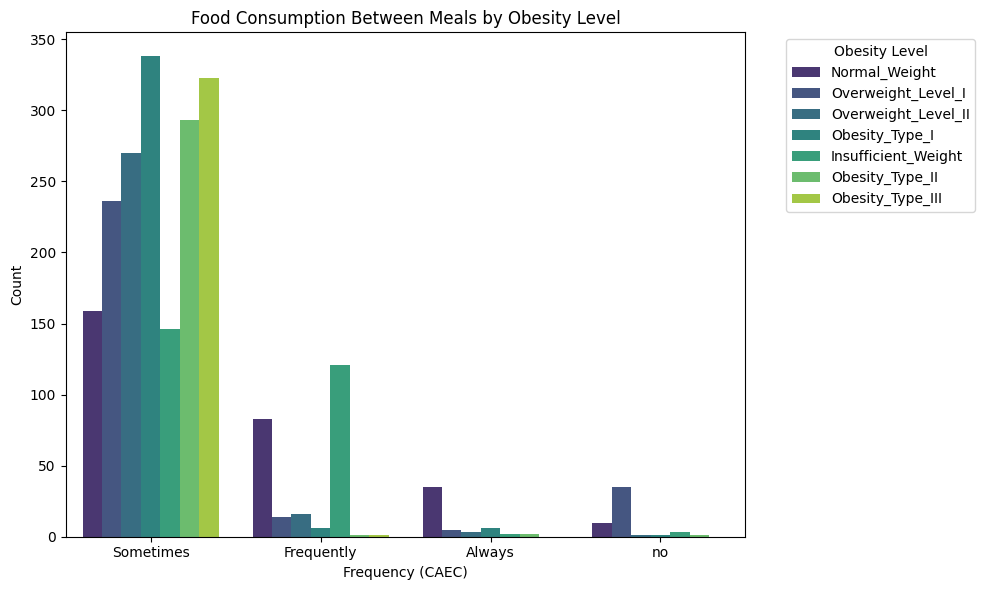

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot: Frequency of Food Consumption Between Meals (CAEC/FreBetweenMeals)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='FreBetweenMeals', hue='TargetObesityL', palette='viridis')

plt.title('Food Consumption Between Meals by Obesity Level')
plt.xlabel('Frequency (CAEC)')
plt.ylabel('Count')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Alcohol Consumption

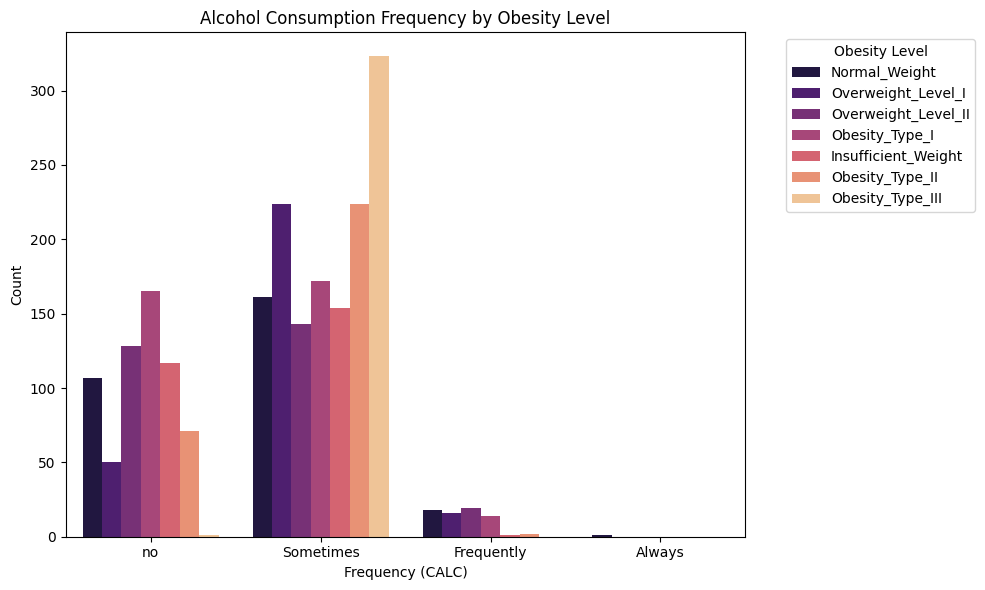

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot: Frequency of Alcohol Consumption (CALC/FreAlcCons)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='FreAlcCons', hue='TargetObesityL', palette='magma')

plt.title('Alcohol Consumption Frequency by Obesity Level')
plt.xlabel('Frequency (CALC)')
plt.ylabel('Count')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



> Exploring the frequency of eating between meals, alcohol consumption, and how physical activity levels vary with age. These insights will help refine our understanding of the dataset's behavioral patterns.
>
>
> *   **Eating & Drinking Habits**: The side-by-side count plots show how snack frequency (`FreBetweenMeals`) and alcohol consumption (`FreAlcCons`) correlate with obesity levels. You'll notice that 'Sometimes' is the dominant snack frequency across most levels, while alcohol consumption patterns show distinct clusters for 'no' and 'sometimes'.


#### Physical Activity Frequency across Age Groups and Gender

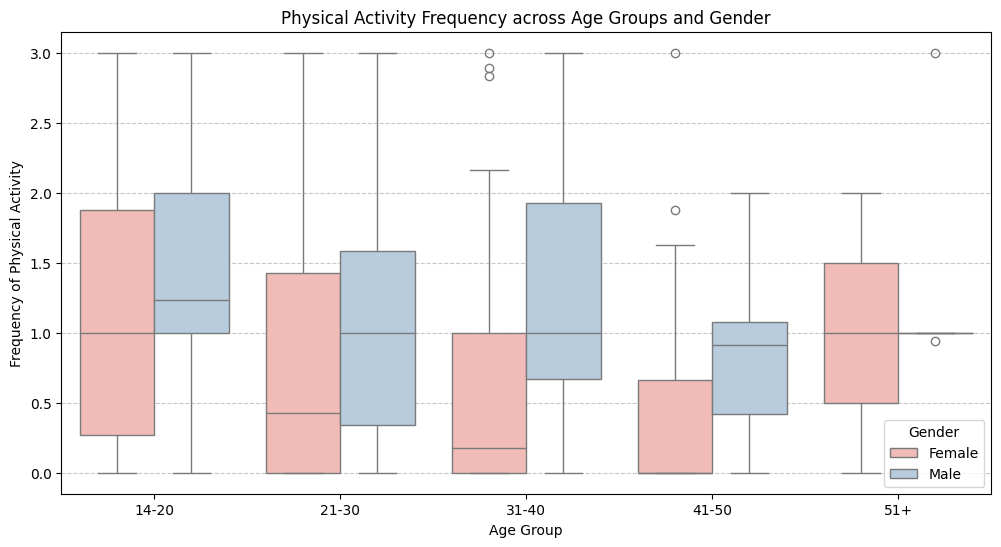

In [172]:
# Relationship between Physical Activity and Age Groups
# Binning Age into groups for better visualization
df_temp = df.copy()
df_temp['AgeGroup'] = pd.cut(df_temp['Age'], bins=[14, 20, 30, 40, 50, 65], labels=['14-20', '21-30', '31-40', '41-50', '51+'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_temp, x='AgeGroup', y='FrePhyAc', hue='Gender', palette='Pastel1')
plt.title('Physical Activity Frequency across Age Groups and Gender')
plt.xlabel('Age Group')
plt.ylabel('Frequency of Physical Activity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Demographic Trends: The boxplot illustrates physical activity frequency across age groups. This gives us a clear look at how active different generations and genders are, helping identify if younger cohorts are significantly more active than older ones within this dataset.

## 2.4 Hypothetical Exploration

### Obesity Levels remain constant across MTransp

* **Null Hypothesis (H₀):** The average Obesity is the same for all means of transportation
 (e.g., Public, Car, Bike, walking).

* **Alternate Hypothesis (H₁):** At least one means of transportation has a different average of Obesity.

In [173]:
# Perform Statistical Test to obtain P-Value
from statsmodels.formula.api import ols
import statsmodels.api as sm

# dfCat.rename(columns={'CSAT Score': 'csat_score', 'Agent Shift': 'agent_shift'}, inplace=True)

model = ols('TargetObesityL ~ C(MTransp)', data=dfTargetEnc).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq      df          F        PR(>F)
C(MTransp)   197.146866     4.0  12.787321  2.755818e-10
Residual    8117.245365  2106.0        NaN           NaN


ANOVA is used to compare the means of a numeric variable (TargetObesityL) across more than two independent groups (MTransp).



**Interpretation**: Reject the null hypothesis.

There is strong evidence that Means of Transportation has a significant effect on Obesity levels since the p-value is extremely small 2.755818e-10 (<< 0.05), and the F-statistic is large. This means Obesity differs across diferent means of transportation in a way unlikely due to random chance.

### MTransp has no association with 'FreBetweenMeals'

* **Null Hypothesis (H₀):** MTransp and FreBetweenMeals are independent (no association).

* **Alternate Hypothesis (H₁):** MTransp and FreBetweenMeals are associated.

In [175]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency
# Create a contingency table of counts between product category and CSAT Score
contingency_table = pd.crosstab(dfCat['MTransp'], df['FreBetweenMeals'])

# Perform Chi-Square Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p}")

Chi-square statistic: 69.28370301459472
Degrees of freedom: 12
P-value: 4.359764768692693e-10


The Chi-square test is appropriate to assess whether two categorical variables are related.



**Interpretation**

Since the p-value is extremely small 4.359764e-10(<< 0.05), we reject the null hypothesis of independence. This means there is a statistically significant association between MTransp and FreBetweenMeals.

### MTransp has no association with 'FreAlcCons'

* **Null Hypothesis (H₀):** MTransp and FreAlcCons are independent (no association).

* **Alternate Hypothesis (H₁):** MTransp and FreAlcCons are associated.

In [176]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency
# Create a contingency table of counts between product category and CSAT Score
contingency_table = pd.crosstab(dfCat['MTransp'], df['FreAlcCons'])

# Perform Chi-Square Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p}")

Chi-square statistic: 69.30657070695034
Degrees of freedom: 12
P-value: 4.317094159144413e-10


The Chi-square test is appropriate to assess whether two categorical variables are related.



**Interpretation**

Since the p-value is is extremely small 4.317094e-10(<< 0.05), we reject the null hypothesis of independence. This means there is a statistically significant association between MTransp and FreBetweenMeals.

### MTransp are uniformly distributed (no single MTransp dominates)

* **Null Hypothesis (H₀):** All modes of transportation occur with equal frequency (uniform distribution).

* **Alternate Hypothesis (H₁):** At least one mode of transportation occurs more or less frequently than others.

In [177]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency, chisquare

# Count the occurrences of each issue type
issue_counts = df['MTransp'].value_counts()

# Number of unique issue types

num_issue_types = len(issue_counts)

# Expected frequencies assuming uniform distribution
expected_freq = [issue_counts.sum() / num_issue_types] * num_issue_types

# Perform Chi-Square Goodness-of-Fit test
chi_stat, p_value = chisquare(f_obs=issue_counts, f_exp=expected_freq)

print(f"Chi-square statistic: {chi_stat}")
print(f"P-value: {p_value}")

Chi-square statistic: 4304.3363334912365
P-value: 0.0


This test is used when you want to compare observed frequencies of categories (issue types) against an expected uniform distribution. It's ideal when testing for the dominance of certain categories.



**Interpretation**

The Chi-Square Goodness-of-Fit test results show a very large chi-square statistic and a p-value of zero, indicating extremely strong evidence against the null hypothesis of uniform distribution. This means that MTransp are not evenly distributed; instead, some MTransp occur significantly more frequently than others.



<a id='preprocess'>

    
# **3. Data Preprocess**
</a>

    
[](#toc)    



In [131]:
print("\n Describe variables")
NumVar=dfClean.describe().T
display(NumVar)


 Describe variables


,count,mean,std,min,25%,50%,75%,max
Gender,2111.0,0.505921,0.500083,0.00,0.000000,1.000000,1.000000,1.00
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FamHist,2111.0,0.817622,0.386247,0.00,1.000000,1.000000,1.000000,1.00
FreHighCal,2111.0,0.883941,0.320371,0.00,1.000000,1.000000,1.000000,1.00
FreVeg,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NumMeals,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
FreBetweenMeals,2111.0,1.140692,0.468543,0.00,1.000000,1.000000,1.000000,3.00
Smoke,2111.0,0.020843,0.142893,0.00,0.000000,0.000000,0.000000,1.00


<div class="alert alert-block alert-info">
    
<a id='skew'></a>

### 3.1. Skewness and kurtosis
    


High skewness often implies the presence of outliers or a non-normal distribution, which might need to be considered during modeling.

High kurtosis in a data set is an indicator that data has heavy tails or outliers. A standard normal distribution has a kurtosis of 3, so values higher than that could indicate presence of outliers. We need to check further this variable about the presence of possible outliers.

In [132]:
dfClean.skew(numeric_only=True).sort_values()

,0
FreHighCal,-2.399125
FamHist,-1.646216
MTransp_Public_Transportation,-1.146063
NumMeals,-1.107097
FreVeg,-0.432906
FreAlcCons,-0.236481
WaterCons,-0.104912
TargetObesityL,-0.076314
Gender,-0.023704
Height,-0.012855


Concerning the variables' skewness, we can conclude the following:

*   **Highly Skewed (absolute value > 1.0):**
    *   `Smoke` (6.71): Very high positive skewness, indicating a large number of 'no' responses and few 'yes' responses.
    *   `MonitorDailyCal` (4.37): High positive skewness, suggesting most individuals do not monitor daily calorie intake.
    *   `Age` (1.53): High positive skewness, meaning there are more younger individuals and fewer older ones.
    *   `NumMeals` (-1.11): High negative skewness.
    *   `FamHist` (-1.65): High negative skewness, suggesting most individuals have a family history with overweight.
    *   `FreHighCal` (-2.40): Very high negative skewness, indicating that the majority frequently consume high-calorie food.

*   **Moderately Skewed (absolute value between 0.5 and 1.0):**
    *   `TimeUseTech` (0.62): Shows moderate positive skewness.

*   **Slightly Skewed or Approximately Symmetrical (absolute value < 0.5):**
    *   `FrePhyAc` (0.50), `Weight` (0.26), `Gender` (-0.02), `Height` (-0.01), `WaterCons` (-0.10), `FreVeg` (-0.43). These variables are relatively symmetrically distributed or have very mild skewness.

High skewness often implies the presence of outliers or a non-normal distribution, which might need to be considered during modeling.

In [133]:
dfClean.kurt(numeric_only=True).sort_values()

,0
Gender,-2.001335
TargetObesityL,-1.222889
WaterCons,-0.879395
Weight,-0.699898
MTransp_Public_Transportation,-0.687192
FreVeg,-0.637546
FrePhyAc,-0.620588
Height,-0.562949
TimeUseTech,-0.548660
FreAlcCons,-0.325943


The kurtosis values provide insights into the 'tailedness' of each variable's distribution. Here's a breakdown of what these results suggest:

*   **Highly Leptokurtic (Kurtosis > 1, indicating heavy tails and potential for more outliers):**
    *   `Smoke` (43.10): This is an extremely high kurtosis, confirming that 'Smoke' is a highly concentrated variable with very few 'yes' values, leading to a very peaked distribution with heavy tails relative to a normal distribution. This is consistent with its high skewness.
    *   `MonitorDailyCal` (17.08): A very high kurtosis suggests that the distribution for 'MonitorDailyCal' is very peaked with heavy tails, implying a large number of values clustered at one end and a few extreme values.
    *   `FreHighCal` (3.76): Shows a notable leptokurtic distribution, indicating a more peaked distribution and heavier tails than a normal distribution.
    *   `Age` (2.83): Moderately leptokurtic, suggesting its distribution is slightly more peaked with somewhat heavier tails compared to a normal distribution.

*   **Platykurtic (Kurtosis < 0, indicating lighter tails and fewer outliers):**
    *   `Gender` (-2.00): As expected for a binary variable, it exhibits a very platykurtic distribution, which is flatter than a normal distribution and has no tails in the traditional sense.
    *   `WaterCons` (-0.88), `Weight` (-0.70), `FreVeg` (-0.64), `FrePhyAc` (-0.62), `Height` (-0.56), `TimeUseTech` (-0.55): These variables display platykurtic distributions. This means their distributions are flatter than a normal distribution, with lighter tails and fewer extreme values (outliers).

*   **Mesokurtic/Slightly Leptokurtic (Kurtosis closer to 0 or slightly positive, similar to a normal distribution in terms of tailedness):**
    *   `NumMeals` (0.39), `FamHist` (0.71): These variables have kurtosis values closer to zero, suggesting their distributions are somewhat similar to a normal distribution in terms of tailedness, or are only slightly more peaked with slightly heavier tails.

### 3.2 (using IQR method) TODO: VERIFY

1.4.1 We will identify outliers in the numerical columns using the Interquartile Range (IQR) method.
This involves calculating the first quartile (Q1), third quartile (Q3), and the IQR for each numerical feature, and then defining upper and lower bounds to detect any values falling outside these ranges.

1.4.1 Use graphical methods (histograms,
scatterplots...), or statistical methods
(Z - score, Isolation Forests...)

**dataset= dfOutliersRemoved**

In [134]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# Identify numerical columns for outlier detection (excluding one-hot encoded and target variable)
# We'll use the 'NumericalCols' list from dfOrdinalEnc, as it contains original numerical features and MTrans is not yet encoded

dfOutliersRemoved =dfOrdinalEnc.copy()
print("Identifying outliers using the IQR method:")

OutlierSummary = {} # Dictionary to store outlier counts

# Define NumericColumns here
NumericColumns = dfOutliersRemoved.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'TargetObesityL' in NumericColumns:
    NumericColumns.remove('TargetObesityL')

for Col in NumericColumns:
    Q1 = dfOutliersRemoved[Col].quantile(0.25)
    Q3 = dfOutliersRemoved[Col].quantile(0.75)
    IQR = Q3 - Q1

    LowerBound = Q1 - 1.5 * IQR
    UpperBound = Q3 + 1.5 * IQR

    # Identify outliers
    Outliers = dfOutliersRemoved[(dfOutliersRemoved[Col] < LowerBound) | (dfOutliersRemoved[Col] > UpperBound)]

    # Store the count of outliers
    OutlierSummary[Col] = len(Outliers)

    if not Outliers.empty:
        print(f"\nColumn '{Col}': {len(Outliers)} outliers detected (min: {Outliers[Col].min()}, max: {Outliers[Col].max()})")
        # if len(Outliers) < 3:
        display(Outliers[[Col]].head())

print("\nSummary of Outliers Detected:")
for Col, Count in OutlierSummary.items():
   if Count > 0: print(f"'{Col}': {Count} outliers")

Identifying outliers using the IQR method:

Column 'Age': 168 outliers detected (min: 35.125401, max: 61.0)


,Age
13,41.0
21,52.0
33,39.0
92,55.0
104,38.0



Column 'Height': 1 outliers detected (min: 1.98, max: 1.98)


,Height
349,1.98



Column 'Weight': 1 outliers detected (min: 173.0, max: 173.0)


...


Column 'MonitorDailyCal': 96 outliers detected (min: 1, max: 1)


,MonitorDailyCal
1,1
11,1
15,1
28,1
36,1



Column 'FreAlcCons': 1 outliers detected (min: 3.0, max: 3.0)


,FreAlcCons
26,3.0



Summary of Outliers Detected:
'Age': 168 outliers
'Height': 1 outliers
'Weight': 1 outliers
'FamHist': 385 outliers
'FreHighCal': 245 outliers
'NumMeals': 579 outliers
'FreBetweenMeals': 346 outliers
'Smoke': 44 outliers
'MonitorDailyCal': 96 outliers
'FreAlcCons': 1 outliers


Transforming Outliers

In [135]:
dfOutliersRemoved = dfOrdinalEnc.copy()

# Identify numerical columns for outlier detection (excluding the encoded target variable)
NumericColumns = dfOutliersRemoved.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'TargetObesityL' in NumericColumns:
    NumericColumns.remove('TargetObesityL')

initial_rows = len(dfOutliersRemoved)
print(f"Initial number of rows: {initial_rows}")

rows_to_drop_indices = set()

for col in NumericColumns:
    Q1 = dfOutliersRemoved[col].quantile(0.25)
    Q3 = dfOutliersRemoved[col].quantile(0.75)
    IQR = Q3 - Q1

    LowerBound = Q1 - 1.5 * IQR
    UpperBound = Q3 + 1.5 * IQR

    # Collect indices of outliers for the current column
    outlier_indices = dfOutliersRemoved[(dfOutliersRemoved[col] < LowerBound) | (dfOutliersRemoved[col] > UpperBound)].index
    rows_to_drop_indices.update(outlier_indices)

# Drop all identified outlier rows at once
dfOutliersRemoved = dfOutliersRemoved.drop(index=list(rows_to_drop_indices))

# Replacing outlier `FreAlcCons` with value 2 (frequently) instead of 3 (always)
# This is done after IQR based removal to ensure we only modify valid remaining rows.
dfOutliersRemoved.loc[dfOutliersRemoved['FreAlcCons'] == 3.0, 'FreAlcCons'] = 2.0

print(f"Number of rows after outlier removal: {len(dfOutliersRemoved)}")
dfOutliersRemoved.info()

Initial number of rows: 2111
Number of rows after outlier removal: 980
<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 6 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           980 non-null    int64  
 1   Age              980 non-null    float64
 2   Height           980 non-null    float64
 3   Weight           980 non-null    float64
 4   FamHist          980 non-null    int64  
 5   FreHighCal       980 non-null    int64  
 6   FreVeg           980 non-null    float64
 7   NumMeals         980 non-null    float64
 8   FreBetweenMeals  980 non-null    float64
 9   Smoke            980 non-null    int64  
 10  WaterCons        980 non-null    float64
 11  MonitorDailyCal  980 non-null    int64  
 12  FrePhyAc         980 non-null    float64
 13  TimeUseTech      980 non-null    float64
 14  FreAlcCons       980 non-null    float64
 15  MTransp          980 non-null    object 


- Column 'FreBetweenMeals': 344 outliers detected.
- Column 'Age': 168 outliers detected.
- Column 'MonitorDailyCal': 96 outliers detected.
- Column 'NumMeals': 579 outliers detected.
- Column 'Height': 1 outliers detected.

  - Column 'Weight': 0 outliers detected.
  - Column 'FreAlcCons': 0 outliers detected.
  - Column 'FreVeg': 0 outliers detected.
  - Column 'WaterCons': 0 outliers detected.
  - Column 'FrePhyAc': 0 outliers detected.
  - Column 'TimeUseTech': 0 outliers detected.

In [139]:
import numpy as np

dfCurrent = dfOutliersRemoved.copy()
InitialRows = len(dfCurrent)

# Columns to re-check for outliers and potentially remove
# ColsToCheck = ['FreBetweenMeals', 'Height', 'Weight','FreAlcCons','Age','MonitorDailyCal','FreVeg', 'NumMeals', 'WaterCons', 'FrePhyAc', 'TimeUseTech']
ColsToCheck = ['Height']

RowsToDrop = set()

print("Identifying and collecting outlier rows for removal:")
for Col in ColsToCheck:
    Q1 = dfCurrent[Col].quantile(0.25)
    Q3 = dfCurrent[Col].quantile(0.75)
    IQR = Q3 - Q1

    LowerBound = Q1 - 1.5 * IQR
    UpperBound = Q3 + 1.5 * IQR

    # Find indices of outliers
    OutlierIndices = dfCurrent[(dfCurrent[Col] < LowerBound) | (dfCurrent[Col] > UpperBound)].index
    RowsToDrop.update(OutlierIndices)
    print(f"  - Column '{Col}': {len(OutlierIndices)} outliers detected.")

print(f"\nTotal unique rows to drop based on selected columns: {len(RowsToDrop)}")

# Drop the identified rows
dfOutliersRemoved = dfCurrent.drop(index=list(RowsToDrop))

print(f"Original rows in dfOutliersRemoved: {InitialRows}")
print(f"Rows after removing selected outliers: {len(dfOutliersRemoved)}")

# Display info of the new DataFrame
dfOutliersRemoved.info()

Identifying and collecting outlier rows for removal:
  - Column 'Height': 1 outliers detected.

Total unique rows to drop based on selected columns: 1
Original rows in dfOutliersRemoved: 980
Rows after removing selected outliers: 979
<class 'pandas.core.frame.DataFrame'>
Index: 979 entries, 6 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           979 non-null    int64  
 1   Age              979 non-null    float64
 2   Height           979 non-null    float64
 3   Weight           979 non-null    float64
 4   FamHist          979 non-null    int64  
 5   FreHighCal       979 non-null    int64  
 6   FreVeg           979 non-null    float64
 7   NumMeals         979 non-null    float64
 8   FreBetweenMeals  979 non-null    float64
 9   Smoke            979 non-null    int64  
 10  WaterCons        979 non-null    float64
 11  MonitorDailyCal  979 non-null    int64  
 12  FrePhyAc        

<div class="alert alert-block alert-info">
    
<a id='new'></a>

### 3.3 Create new variables
    

Create new variables in order to get variables with higher predictive power.

In [140]:
dfTransformed =dfOutliersRemoved.copy()
dfTransformed['Weight_Height'] =  dfOutliersRemoved['Weight'] / dfOutliersRemoved['Height']
dfTransformed['Age_Height'] = dfOutliersRemoved['Age'] / dfOutliersRemoved['Height']
dfTransformed['Age_Weight'] = dfOutliersRemoved['Age'] / dfOutliersRemoved['Weight']
display(dfTransformed)

,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL,Weight_Height,Age_Height,Age_Weight
6,0,23.000000,1.500000,55.000000,1,1,3.0,3.0,1.0,0,2.000000,0,1.000000,0.000000,1.0,Motorbike,Normal_Weight,36.666667,15.333333,0.418182
8,1,24.000000,1.780000,64.000000,1,1,3.0,3.0,1.0,0,2.000000,0,1.000000,1.000000,2.0,Public_Transportation,Normal_Weight,35.955056,13.483146,0.375000
9,1,22.000000,1.720000,68.000000,1,1,2.0,3.0,1.0,0,2.000000,0,1.000000,1.000000,0.0,Public_Transportation,Normal_Weight,39.534884,12.790698,0.323529
22,0,22.000000,1.650000,60.000000,1,1,3.0,3.0,1.0,0,2.000000,0,1.000000,0.000000,1.0,Automobile,Normal_Weight,36.363636,13.333333,0.366667
24,1,21.000000,1.850000,68.000000,1,1,2.0,3.0,1.0,0,2.000000,0,0.000000,1.000000,1.0,Public_Transportation,Normal_Weight,36.756757,11.351351,0.308824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,1.0,0,1.728139,0,1.676269,0.906247,1.0,Public_Transportation,Obesity_Type_III,76.814300,12.261924,0.159631
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,1.0,0,2.005130,0,1.341390,0.599270,1.0,Public_Transportation,Obesity_Type_III,76.486427,12.571854,0.164367
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,1.0,0,2.054193,0,1.414209,0.646288,1.0,Public_Transportation,Obesity_Type_III,76.297737,12.854673,0.168480
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,1.0,0,2.852339,0,1.139107,0.586035,1.0,Public_Transportation,Obesity_Type_III,76.660232,14.005540,0.182696


<div class="alert alert-block alert-info">
    
<a id='scale'></a>

### 3.4. Scaling
    


In [141]:
from sklearn.preprocessing import StandardScaler

dfScaled = dfClean.copy()

# Identify numerical columns for scaling (excluding the encoded target variable)
NumericalCols = dfScaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
NumericalCols.remove('TargetObesityL') # Exclude the target variable from scaling

# Initialize the StandardScaler
Scaler = StandardScaler()

# Apply scaling to the numerical columns
dfScaled[NumericalCols] = Scaler.fit_transform(dfScaled[NumericalCols])

print("\nDataFrame after feature scaling:")
display(dfScaled.head())


DataFrame after feature scaling:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,...,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,TargetObesityL,MTransp_Automobile,MTransp_Bike,MTransp_Motorbike,MTransp_Public_Transportation,MTransp_Walking
0,-1.011914,-0.522124,-0.875589,-0.862558,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,-1.188039,0.561997,-1.419172,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
1,-1.011914,-0.522124,-1.947599,-1.168077,0.472291,-2.759769,1.088342,0.404153,-0.300346,6.853997,...,4.581439,2.339750,-1.080625,0.521160,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
2,0.988227,-0.206889,1.054029,-0.366090,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,0.561997,2.461491,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
3,0.988227,0.423582,1.054029,0.015808,-2.117337,-2.759769,1.088342,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,-1.080625,2.461491,2.0,-0.525642,-0.05768,-0.072375,-1.724969,6.057758
4,0.988227,-0.364507,0.839627,0.122740,-2.117337,-2.759769,-0.785019,-2.167023,-0.300346,-0.145900,...,-0.218272,-1.188039,-1.080625,0.521160,3.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078


# Class Imbalance TODO: Still need to aply this if nedded Target MTransp

In [130]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np # Import numpy

# Ensure X_train and Y_train are defined for this cell
# Use dfClean, and drop 'Weight' and 'Height' as per previous models to prevent target leakage
df_temp = dfClean.copy()
X_temp = df_temp.drop(columns=['TargetObesityL', 'Weight', 'Height'])
Y_temp = df_temp['TargetObesityL']

# Perform a fresh train/test split to ensure Y_train is defined
# Use random_state for reproducibility and stratify for class balance in split
X_train_resample, X_test_resample, Y_train_resample, Y_test_resample = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42, stratify=Y_temp)


print("Original class distribution in Y_train_resample:", Counter(Y_train_resample))

# --- Option 1: Using SMOTE for Resampling ---
# This is a general approach that works for all models, especially useful for KNN and Gradient Boosting
# since they don't have a direct `class_weight` parameter.

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train_resample, Y_train_resample)

print("Class distribution after SMOTE:", Counter(y_resampled))
print("\n--- How to use the resampled data ---")
print("You can now train your models using X_resampled and y_resampled, for example:")
print("LogModel.fit(X_resampled, y_resampled)")

# --- Option 2: Using class_weight='balanced' parameter ---
# For models that support it (Logistic Regression, Decision Trees, Random Forest, SVM),
# you can set the `class_weight` parameter directly in the model constructor.

print("\n--- Example for models supporting 'class_weight' ---")
print("For Logistic Regression, Decision Trees, Random Forest, and SVM, you can instantiate the model like this:")
print("from sklearn.linear_model import LogisticRegression")
print("LogModel = LogisticRegression(max_iter=2000, class_weight='balanced')")
print("LogModel.fit(X_train_resample, Y_train_resample) # Train on original data, weights handled internally")

# Alternatively, you can compute custom class weights manually and pass them
# This might be useful if you want more fine-grained control than 'balanced'
unique_classes = sorted(Y_train_resample.unique())
weights = class_weight.compute_class_weight('balanced', classes=np.array(unique_classes), y=Y_train_resample) # Convert to numpy array
class_weights_dict = dict(zip(unique_classes, weights))
print("\nExample of computed class weights:", class_weights_dict)
print("Then, you would pass this dictionary to the `class_weight` parameter:")
print("LogModel = LogisticRegression(max_iter=2000, class_weight=class_weights_dict)")

Original class distribution in Y_train_resample: Counter({4.0: 281, 6.0: 259, 5.0: 237, 3.0: 232, 2.0: 232, 1.0: 229, 0.0: 218})
Class distribution after SMOTE: Counter({1.0: 281, 0.0: 281, 4.0: 281, 6.0: 281, 3.0: 281, 2.0: 281, 5.0: 281})

--- How to use the resampled data ---
You can now train your models using X_resampled and y_resampled, for example:
LogModel.fit(X_resampled, y_resampled)

--- Example for models supporting 'class_weight' ---
For Logistic Regression, Decision Trees, Random Forest, and SVM, you can instantiate the model like this:
from sklearn.linear_model import LogisticRegression
LogModel = LogisticRegression(max_iter=2000, class_weight='balanced')
LogModel.fit(X_train_resample, Y_train_resample) # Train on original data, weights handled internally

Example of computed class weights: {np.float64(0.0): np.float64(1.1061598951507208), np.float64(1.0): np.float64(1.0530255770430443), np.float64(2.0): np.float64(1.0394088669950738), np.float64(3.0): np.float64(1.03940

In [142]:
dfCat.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'FamHist', 'FreHighCal', 'FreVeg',
       'NumMeals', 'FreBetweenMeals', 'Smoke', 'WaterCons', 'MonitorDailyCal',
       'FrePhyAc', 'TimeUseTech', 'FreAlcCons', 'MTransp', 'TargetObesityL'],
      dtype='object')

### Augmented Data

In [143]:
df_onehot = dfClean.copy()
df_onehot["Growth_Rate"] = df_onehot["Height"] / df_onehot["Age"]
df_onehot.head()

,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,...,FrePhyAc,TimeUseTech,FreAlcCons,TargetObesityL,MTransp_Automobile,MTransp_Bike,MTransp_Motorbike,MTransp_Public_Transportation,MTransp_Walking,Growth_Rate
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1.0,0,...,0.0,1.0,0.0,1.0,0,0,0,1,0,0.077143
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1.0,1,...,3.0,0.0,1.0,1.0,0,0,0,1,0,0.072381
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1.0,0,...,2.0,1.0,2.0,1.0,0,0,0,1,0,0.078261
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1.0,0,...,2.0,0.0,2.0,2.0,0,0,0,0,1,0.066667
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1.0,0,...,0.0,0.0,1.0,3.0,0,0,0,1,0,0.080909




<a id='depth'>

    
# **4. Questions**
</a>

    
[](#toc)    




In [144]:
# List of all Datasets after Preprocessing

print("df.head() Original Dataset with Variables renamed:")
display(df.head())
print("\ndfCat.head() Changed only binary variables, maintainde categorical:")
display(dfCat.head())
print("\ndfOrdinalEnc.head() Only ordinal encoding, MTrans still categorical:")
display(dfOrdinalEnc.head())
print("\ndfTargetEnc.head() Target encoding,, MTrans still categorical :")
display(dfTargetEnc.head())
print("\ndfClean.head(), MTrans one-hot encoding:")
display(dfClean.head())

# Outliers and other Transf
print("\ndfOutliersRemoved.head() Is not necessary to remove them all:")
display(dfOutliersRemoved.head())
print("\ndfTransformed.head():")
display(dfTransformed.head())
print("\ndfScaled.head():")
display(dfScaled.head())

df.head() Original Dataset with Variables renamed:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



dfCat.head() Changed only binary variables, maintainde categorical:


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



dfOrdinalEnc.head() Only ordinal encoding, MTrans still categorical:


...

,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL
6,0,23.0,1.50,55.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Motorbike,Normal_Weight
8,1,24.0,1.78,64.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,1.0,2.0,Public_Transportation,Normal_Weight
9,1,22.0,1.72,68.0,1,1,2.0,3.0,1.0,0,2.0,0,1.0,1.0,0.0,Public_Transportation,Normal_Weight
22,0,22.0,1.65,60.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Automobile,Normal_Weight
24,1,21.0,1.85,68.0,1,1,2.0,3.0,1.0,0,2.0,0,0.0,1.0,1.0,Public_Transportation,Normal_Weight



dfTransformed.head():


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,MTransp,TargetObesityL,Weight_Height,Age_Height,Age_Weight
6,0,23.0,1.50,55.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Motorbike,Normal_Weight,36.666667,15.333333,0.418182
8,1,24.0,1.78,64.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,1.0,2.0,Public_Transportation,Normal_Weight,35.955056,13.483146,0.375000
9,1,22.0,1.72,68.0,1,1,2.0,3.0,1.0,0,2.0,0,1.0,1.0,0.0,Public_Transportation,Normal_Weight,39.534884,12.790698,0.323529
22,0,22.0,1.65,60.0,1,1,3.0,3.0,1.0,0,2.0,0,1.0,0.0,1.0,Automobile,Normal_Weight,36.363636,13.333333,0.366667
24,1,21.0,1.85,68.0,1,1,2.0,3.0,1.0,0,2.0,0,0.0,1.0,1.0,Public_Transportation,Normal_Weight,36.756757,11.351351,0.308824



dfScaled.head():


,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,...,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,TargetObesityL,MTransp_Automobile,MTransp_Bike,MTransp_Motorbike,MTransp_Public_Transportation,MTransp_Walking
0,-1.011914,-0.522124,-0.875589,-0.862558,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,-1.188039,0.561997,-1.419172,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
1,-1.011914,-0.522124,-1.947599,-1.168077,0.472291,-2.759769,1.088342,0.404153,-0.300346,6.853997,...,4.581439,2.339750,-1.080625,0.521160,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
2,0.988227,-0.206889,1.054029,-0.366090,0.472291,-2.759769,-0.785019,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,0.561997,2.461491,1.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078
3,0.988227,0.423582,1.054029,0.015808,-2.117337,-2.759769,1.088342,0.404153,-0.300346,-0.145900,...,-0.218272,1.163820,-1.080625,2.461491,2.0,-0.525642,-0.05768,-0.072375,-1.724969,6.057758
4,0.988227,-0.364507,0.839627,0.122740,-2.117337,-2.759769,-0.785019,-2.167023,-0.300346,-0.145900,...,-0.218272,-1.188039,-1.080625,0.521160,3.0,-0.525642,-0.05768,-0.072375,0.579721,-0.165078


In [145]:
# 4. Create a DataFrame to make it easy to read
ObesityLabels = [
    'Insufficient_Weight (0)', 'Normal_Weight (1)', 'Overweight_I (2)',
    'Overweight_II (3)', 'Obesity_I (4)', 'Obesity_II (5)', 'Obesity_III (6)'
]


<div class="alert alert-block alert-info">
    
<a id='inDepht_1'></a>

### 4.1. Do physical activity levels significantly influence obesity classification?
    



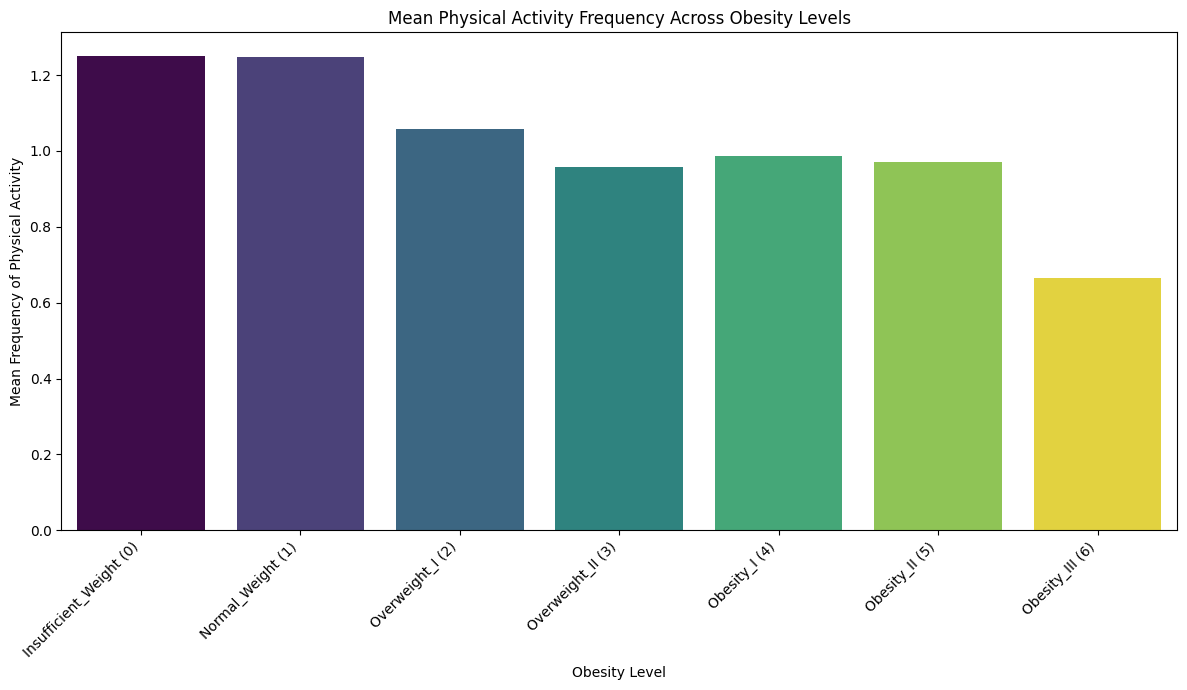

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean physical activity frequency for each Obesity Level
mean_phy_ac_by_obesity = dfClean.groupby('TargetObesityL')['FrePhyAc'].mean().reset_index()

# Define numerical order for the x-axis
obesity_numeric_order = sorted(dfClean['TargetObesityL'].unique())

plt.figure(figsize=(12, 7))
sns.barplot(x='TargetObesityL', y='FrePhyAc', data=mean_phy_ac_by_obesity, order=obesity_numeric_order, palette='viridis', hue='TargetObesityL', legend=False)
plt.title('Mean Physical Activity Frequency Across Obesity Levels')
plt.xlabel('Obesity Level')
plt.ylabel('Mean Frequency of Physical Activity')
# Use ObesityLabels for readable tick labels
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    
<a id='inDepht_2'></a>

### 4.2. Are eating habits stronger predictors of obesity than demographic factors?
    




In [147]:
dfOrdinalEnc.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'FamHist', 'FreHighCal', 'FreVeg',
       'NumMeals', 'FreBetweenMeals', 'Smoke', 'WaterCons', 'MonitorDailyCal',
       'FrePhyAc', 'TimeUseTech', 'FreAlcCons', 'MTransp', 'TargetObesityL'],
      dtype='object')

To determine whether eating habits are stronger predictors of obesity than demographic factors, we can refer to the feature importance results from the Random Forest and Tuned Gradient Boosting models, along with the coefficient analysis from Logistic Regression.

**Insights from Random Forest (without 'Weight' feature)**

(Using `FeatureImportanceDfNl`)

*   **Top Individual Predictors:**
    *   `Age` (Demographic): 0.141877
    *   `FreVeg` (Eating Habit): 0.123820
    *   `NumMeals` (Eating Habit): 0.083827
    *   `WaterCons` (Eating Habit): 0.07734778
    *   `Gender` (Demographic): 0.05678053
    *   `FreBetweenMeals` (Eating Habit): 0.0504126
    *   `FreAlcCons` (Eating Habit): 0.0496179
    *   `FamHist` (Demographic): 0.04532674

*   **Summary:** 'Age' stands out as the single strongest predictor. However, several eating habits (`FreVeg`, `NumMeals`, `WaterCons`, `FreBetweenMeals`, `FreAlcCons`) follow closely, and collectively, the eating habits features show a substantial combined importance.

**Insights from Tuned Gradient Boosting Model**
(Using `feature_importance_df_gb`)

*   **Top Individual Predictors:**
    *   `Age` (Demographic): 0.172327
    *   `FreVeg` (Eating Habit): 0.163572
    *   `NumMeals` (Eating Habit): 0.079754
    *   `Gender` (Demographic): 0.075494
    *   `FreBetweenMeals` (Eating Habit): 0.070364
    *   `WaterCons` (Eating Habit): 0.064590
    *   `FamHist` (Demographic): 0.055374
    *   `FreAlcCons` (Eating Habit): 0.044812

*   **Summary:** Similar to the Random Forest, 'Age' is the strongest predictor, with `FreVeg` being a very close second. The set of eating habits collectively demonstrates significant predictive power, often outweighing demographic factors when considered as a group.

**Insights from Logistic Regression (Coefficient Heatmap)**

The Logistic Regression heatmap for the model (without 'Weight' and 'Height') shows:

*   **Demographic Factors:**
    *   `Age`: Consistently shows positive coefficients for higher obesity levels (e.g., Obesity Type II and III), indicating that older age is associated with an increased likelihood of more severe obesity classifications.
    *   `FamHist`: Positive coefficients for higher obesity levels, suggesting a family history of overweight increases obesity risk.
    *   `Gender`: Has mixed effects, contributing differently across various obesity classifications.

*   **Eating Habits:**
    *   `FreVeg`: Shows strong negative coefficients for most obesity levels, indicating that frequent vegetable consumption decreases the likelihood of obesity. An interesting observation is its positive correlation with `Obesity_III`, which could indicate medical advice for these individuals.
    *   `FreHighCal`: Generally shows positive coefficients for higher obesity levels, meaning frequent consumption of high-calorie food increases obesity risk.
    *   `NumMeals`, `WaterCons`, `FreBetweenMeals`, `FreAlcCons`: Also exhibit varying coefficients, but often show a clear directional impact on obesity levels.

**Conclusion**

While **Age** frequently appears as the single most important individual predictor across models, the collective influence of **eating habits** as a group (including `FreVeg`, `NumMeals`, `WaterCons`, `FreBetweenMeals`, `FreHighCal`, `FreAlcCons`) often demonstrates a stronger or comparable predictive power to demographic factors (`Gender`, `Age`, `FamHist`).

Specifically:

*   **`Age` (demographic) is consistently the strongest individual predictor.**
*   **`FreVeg` (eating habit) is a very strong individual predictor, often ranking second or very close to `Age`.**
*   When considering the **combined impact** of all listed eating habits versus all listed demographic factors, the eating habits collectively tend to be **stronger predictors** of obesity levels. Many eating habits show significant, independent contributions to predicting obesity outcomes.

<div class="alert alert-block alert-info">
    
<a id='inDepht_3'></a>

### 4.3. Is there a relationship between technology usage (screen time) and obesity levels?
    



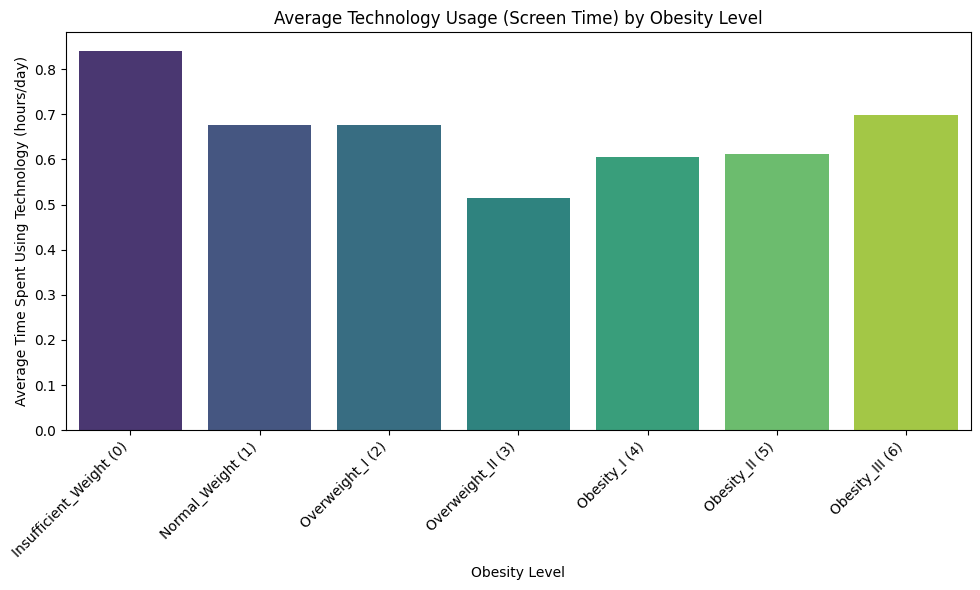

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the mean TimeUseTech for each Obesity Level
mean_time_use_tech = dfOrdinalEnc.groupby('TargetObesityL')['TimeUseTech'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='TargetObesityL', y='TimeUseTech', data=mean_time_use_tech, palette='viridis', hue='TargetObesityL', legend=False)
plt.title('Average Technology Usage (Screen Time) by Obesity Level')
plt.xlabel('Obesity Level')
plt.ylabel('Average Time Spent Using Technology (hours/day)')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

The bar chart visualizes the average time spent using technology across different obesity levels.

From the chart, we can observe the following trends:

*   **Lower Obesity Levels (Insufficient_Weight, Normal_Weight):** These categories generally show lower average technology usage.
*   **Overweight Levels (Overweight_Level_I, Overweight_Level_II):** The average screen time seems to increase slightly in these categories compared to normal weight individuals.
*   **Obesity Types (Obesity_Type_I, Obesity_Type_II, Obesity_Type_III):** The average screen time tends to be higher for individuals in the obesity categories, with 'Obesity_Type_I' showing a noticeable peak in average time spent. Interestingly, 'Obesity_Type_II' and 'Obesity_Type_III' show slightly lower averages than 'Obesity_Type_I', but still higher than 'Insufficient_Weight' and 'Normal_Weight'.

Overall, there appears to be a general positive relationship: individuals in higher obesity classifications tend to report higher average technology usage, although the trend isn't strictly linear across all obesity types. This suggests that increased screen time might be a contributing factor or a correlated behavior with higher obesity levels.

<div class="alert alert-block alert-info">
    
<a id='inDepht_4'></a>

### 4.4. Do transportation habits correlate with healthier lifestyles?
    



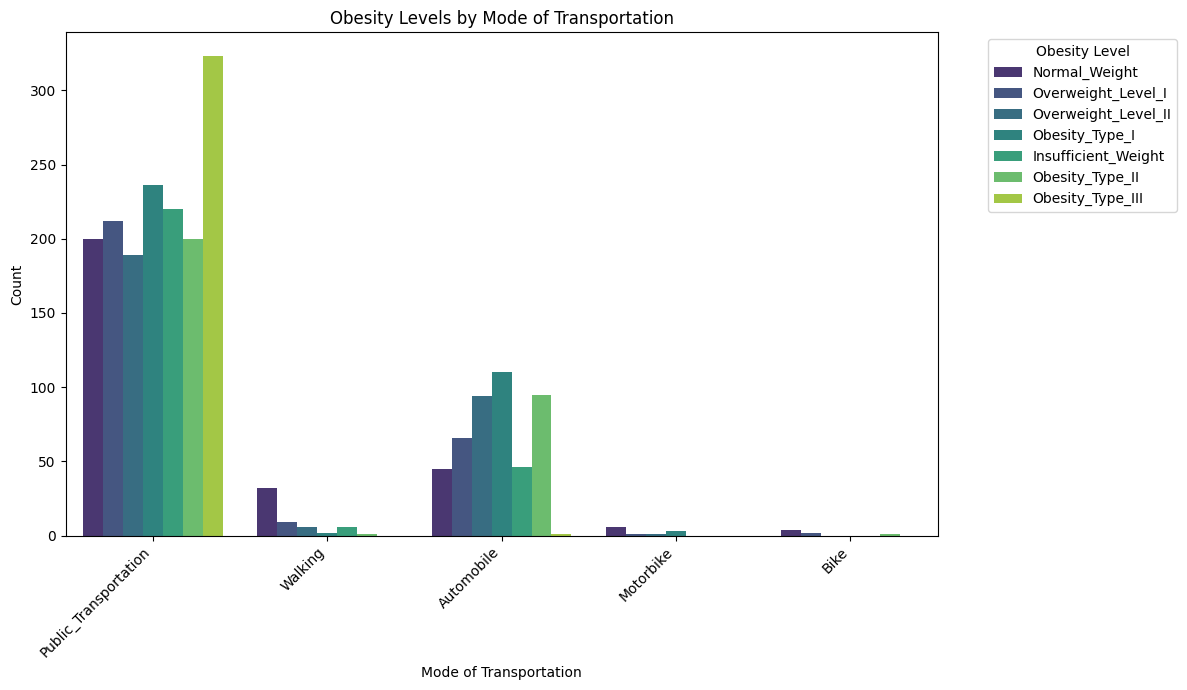

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(x='MTransp', hue='TargetObesityL', data=dfOrdinalEnc, palette='viridis')
plt.title('Obesity Levels by Mode of Transportation')
plt.xlabel('Mode of Transportation')
plt.ylabel('Count')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    
<a id='inDepht_5'></a>

### 4.5. Can obesity patterns vary across age groups or genders?
    



In [150]:
# Define the order of the obesity levels for consistent plotting
ObesityOrder_Labels = [
    'Insufficient Weight',
    'Normal Weight',
    'Overweight Level_I',
    'Overweight Level_II',
    'Obesity Type_I',
    'Obesity Type_II',
    'Obesity Type_III'
]

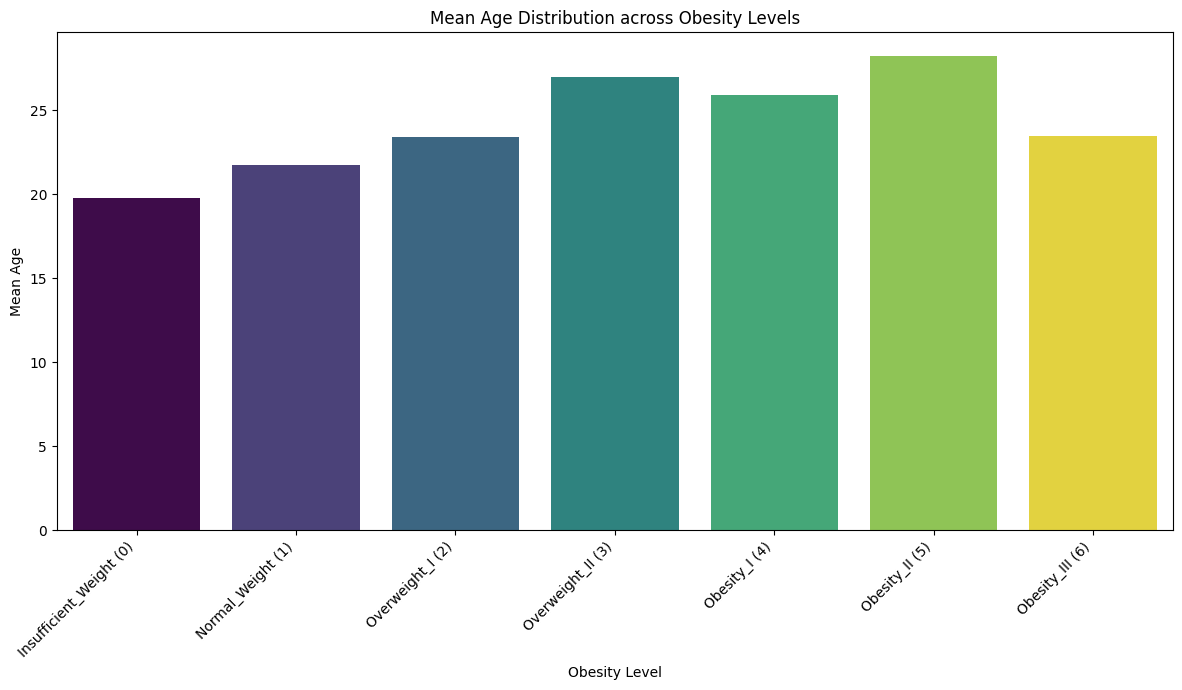

In [151]:
# mean age for each Obesity Level
mean_age_by_obesity = dfClean.groupby('TargetObesityL')['Age'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='TargetObesityL', y='Age', data=mean_age_by_obesity, order=obesity_numeric_order, palette='viridis', hue='TargetObesityL', legend=False)
plt.title('Mean Age Distribution across Obesity Levels')
plt.xlabel('Obesity Level')
plt.ylabel('Mean Age')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

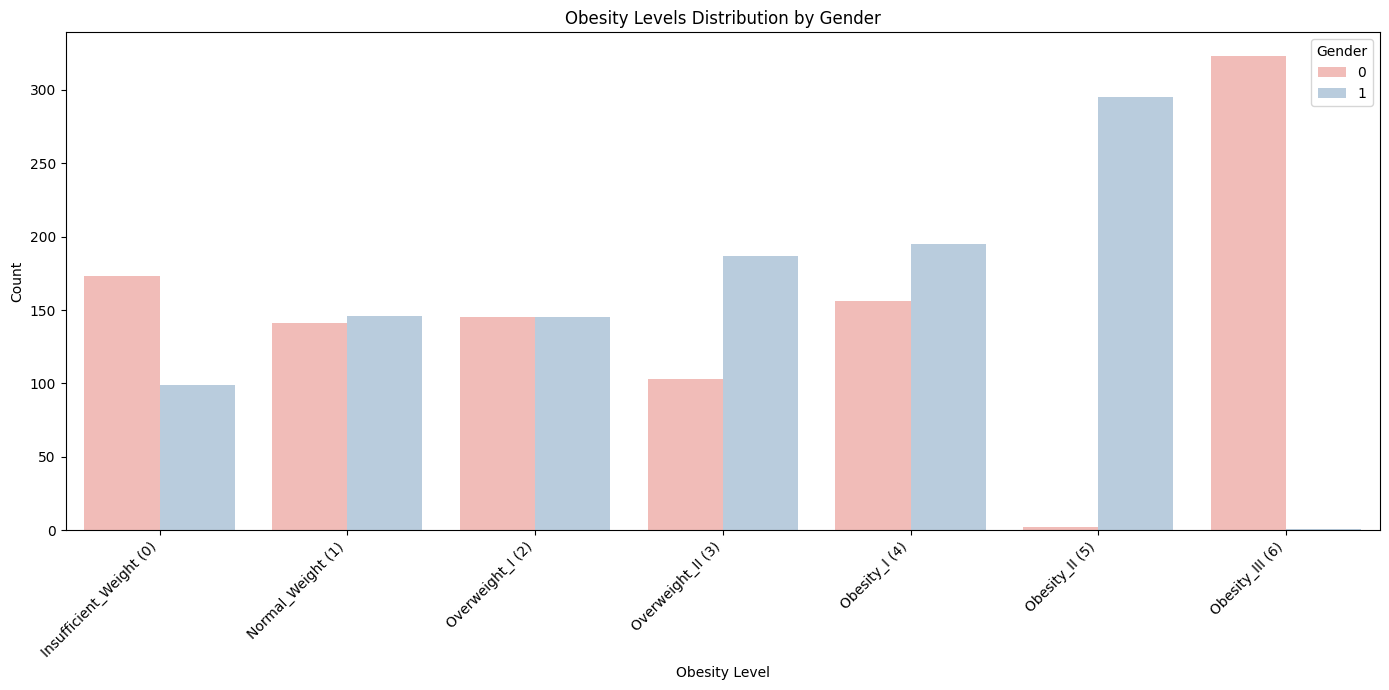

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obesity Levels Distribution by Gender
plt.figure(figsize=(14, 7))
sns.countplot(x='TargetObesityL', hue='Gender', data=dfClean, order=obesity_numeric_order, palette='Pastel1')
plt.title('Obesity Levels Distribution by Gender')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

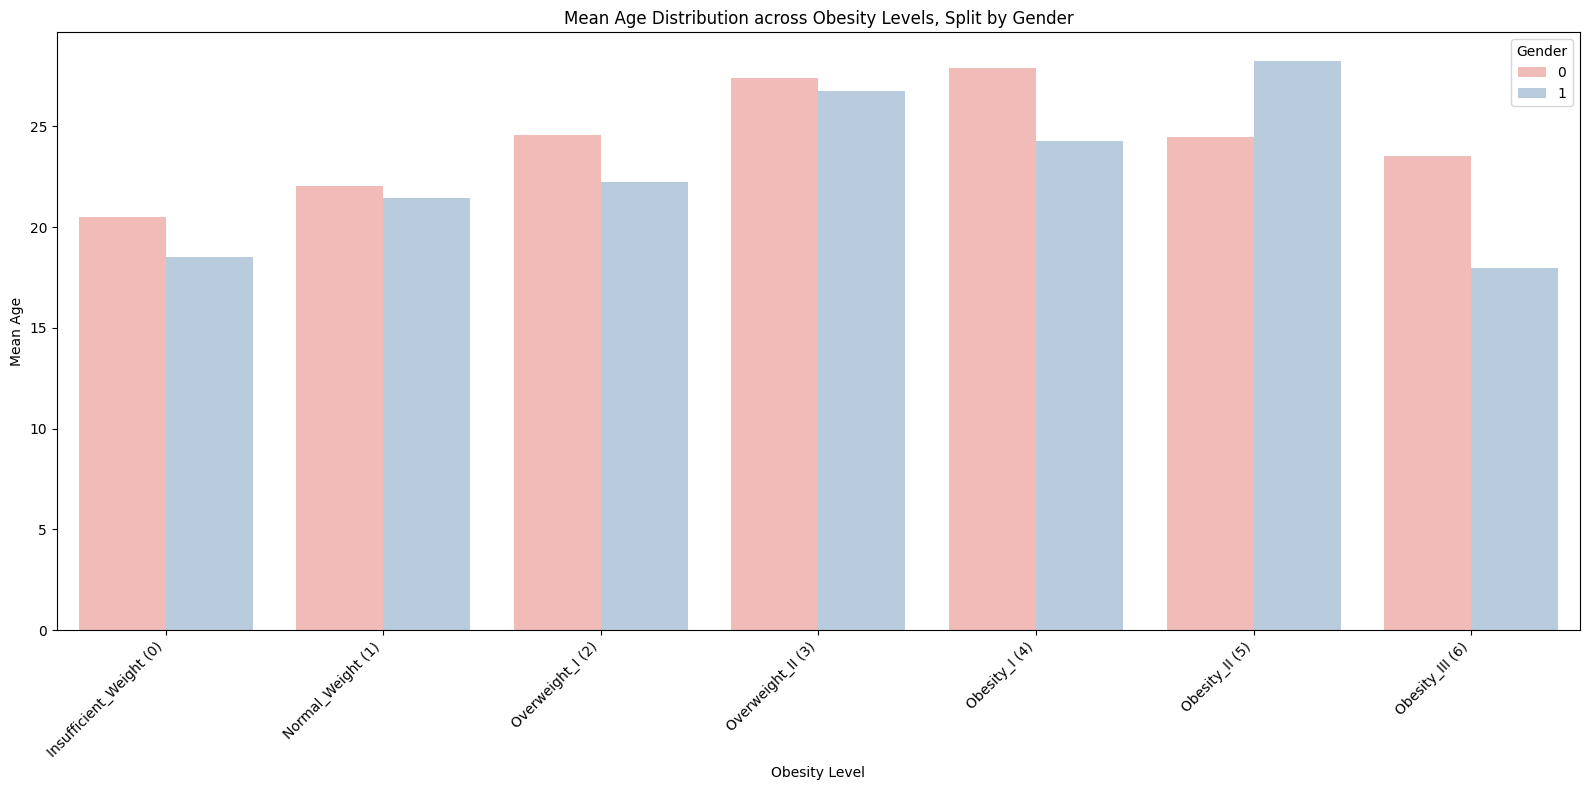

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean age for each Obesity Level, split by Gender
mean_age_by_obesity_gender = dfClean.groupby(['TargetObesityL', 'Gender'])['Age'].mean().reset_index()

plt.figure(figsize=(16, 8))
sns.barplot(x='TargetObesityL', y='Age', hue='Gender', data=mean_age_by_obesity_gender,
            order=obesity_numeric_order, palette='Pastel1')
plt.title('Mean Age Distribution across Obesity Levels, Split by Gender')
plt.xlabel('Obesity Level')
plt.ylabel('Mean Age')
plt.xticks(ticks=range(len(ObesityLabels)), labels=ObesityLabels, rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

The plot showing the 'Mean Age Distribution across Obesity Levels, Split by Gender' provides interesting insights into how age and gender interact with different obesity classifications:

*   **General Trend:** For both genders, there's a general trend of increasing mean age as obesity levels rise, particularly from 'Insufficient Weight' up to 'Obesity Type II'.
*   **Gender Differences in Lower Levels:** In the 'Insufficient Weight', 'Normal Weight', and 'Overweight Level I' categories, females generally have a slightly higher mean age than males.
*   **Gender Differences in Higher Levels:**
    *   For 'Obesity Type I' and 'Obesity Type III', females show a higher mean age compared to males within those categories.
    *   Conversely, for 'Obesity Type II', males have a higher mean age than females.
*   **Notable Observation:** The mean age for males in 'Obesity Type III' is notably lower than for females in the same category, and also lower than males in 'Obesity Type II'. This might suggest different underlying factors or demographic distributions within the most severe obesity classification, or it could be an anomaly worth further investigation.

These patterns suggest that age and gender play complex roles in obesity, with varying mean ages across different obesity levels and distinct distributions between males and females.

##4.6 Relation calories monitor - vegatables intake.

Relation between people who monitor calories intake with vegatables intake.

,count,mean,std,min,25%,50%,75%,max
MonitorDailyCal,,,,,,,,
0,2015,2.410671,0.532063,1.0,2.0,2.33998,3.0,3.0
1,96,2.594763,0.545442,1.0,2.0,3.00000,3.0,3.0


/tmp/ipykernel_10718/1799009795.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MonitorDailyCal', y='FreVeg', data=dfCat, palette='viridis', errorbar='sd')


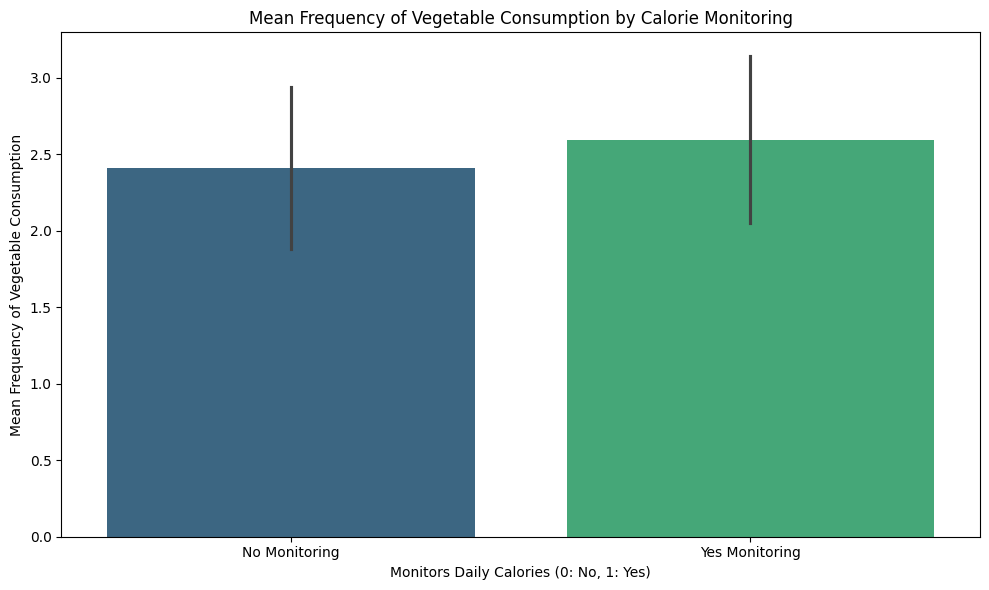

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean vegetable intake for those who monitor calories and those who don't
veg_intake_by_monitor_cal = dfCat.groupby('MonitorDailyCal')['FreVeg'].agg(['count', 'mean', 'std', 'min', ('25%', lambda x: x.quantile(0.25)), ('50%', lambda x: x.quantile(0.50)), ('75%', lambda x: x.quantile(0.75)), 'max'])
display(veg_intake_by_monitor_cal)

# 1. Bar Chart: Mean Frequency of Vegetable Consumption
plt.figure(figsize=(10, 6))
sns.barplot(x='MonitorDailyCal', y='FreVeg', data=dfCat, palette='viridis', errorbar='sd')
plt.title('Mean Frequency of Vegetable Consumption by Calorie Monitoring')
plt.xlabel('Monitors Daily Calories (0: No, 1: Yes)')
plt.ylabel('Mean Frequency of Vegetable Consumption')
plt.xticks(ticks=[0, 1], labels=['No Monitoring', 'Yes Monitoring'])
plt.tight_layout()
plt.show()


From the descriptive statistics, we can observe that individuals who monitor daily calories (MonitorDailyCal = 1) have a slightly higher mean frequency of vegetable consumption (2.59) compared to those who do not monitor (2.41). More notably, the median (50th percentile) vegetable intake is higher for the monitoring group (3.00) than for the non-monitoring group (2.34), indicating a clearer difference in typical consumption habits.

Visualizations:
Mean Frequency of Vegetable Consumption Bar Chart: This plot visually confirms the slightly higher average vegetable intake for individuals who monitor their calories. The error bars show the standard deviation, indicating the variability within each group.

# **5. Predictive Modeling**
<a id='preprocess'></a>



The plot shows the distribution of obesity levels across different modes of transportation.

We can observe that 'Public Transportation' is the most common mode, and it's associated with a wide range of obesity levels, with a notable presence of 'Obesity_Type_I', 'Obesity_Type_II', and 'Obesity_Type_III'.

'Automobile' usage also shows various obesity levels, but with a different distribution compared to public transport.

'Walking' appears to be associated with lower obesity levels, such as 'Normal_Weight' and

'Insufficient_Weight', though the counts are much smaller overall.


'Motorbike' and 'Bike' are used by very few individuals, making it difficult to draw strong conclusions about their association with obesity levels from this plot alone.


These findings suggest that transportation habits do correlate with obesity patterns, particularly with public transportation and walking.

<div class="alert alert-block alert-warning">

<a id='clean'></a>

## 5.1 Logistic Regression
    


In [155]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# 1. Start fresh from dfClean to guarantee no messy notebook memory
dfFinal = dfClean.copy()

# 2. Define EXACTLY which columns are continuous numbers
# Notice: No categorical/text columns are in this list!
ContinuousCols = ['Age', 'Height', 'Weight', 'FreVeg', 'NumMeals', 'WaterCons', 'FrePhyAc', 'TimeUseTech']

# 3. Scale only those continuous columns
Scaler = StandardScaler()
dfFinal[ContinuousCols] = Scaler.fit_transform(dfFinal[ContinuousCols])
dfFinal.info()

# 4. Separate Features (X) and Target (Y)
X = dfFinal.drop(columns=['TargetObesityL'])
Y = dfFinal['TargetObesityL']

# 5. Train/Test Split (80% training, 20% testing)
XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 6. Train Logistic Regression
# We set max_iter=2000 to ensure the math has enough time to converge
LogModel = LogisticRegression(max_iter=2000)
LogModel.fit(XTrain, YTrain)

# 7. Predict and Evaluate
YPred = LogModel.predict(XTest)

print("--- Logistic Regression Performance ---")
print(f"Accuracy:  {accuracy_score(YTest, YPred):.4f}")
print(f"Precision: {precision_score(YTest, YPred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(YTest, YPred, average='weighted'):.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(YTest, YPred))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         2111 non-null   int64  
 1   Age                            2111 non-null   float64
 2   Height                         2111 non-null   float64
 3   Weight                         2111 non-null   float64
 4   FamHist                        2111 non-null   int64  
 5   FreHighCal                     2111 non-null   int64  
 6   FreVeg                         2111 non-null   float64
 7   NumMeals                       2111 non-null   float64
 8   FreBetweenMeals                2111 non-null   float64
 9   Smoke                          2111 non-null   int64  
 10  WaterCons                      2111 non-null   float64
 11  MonitorDailyCal                2111 non-null   int64  
 12  FrePhyAc                       2111 non-null   f

<div class="alert alert-block alert-warning">

<a id='clean'></a>

## 5.2 Random Forest to confirm the most important predictors
    


--- Random Forest Performance ---
Accuracy:  0.9433
Precision: 0.9479
Recall:    0.9433


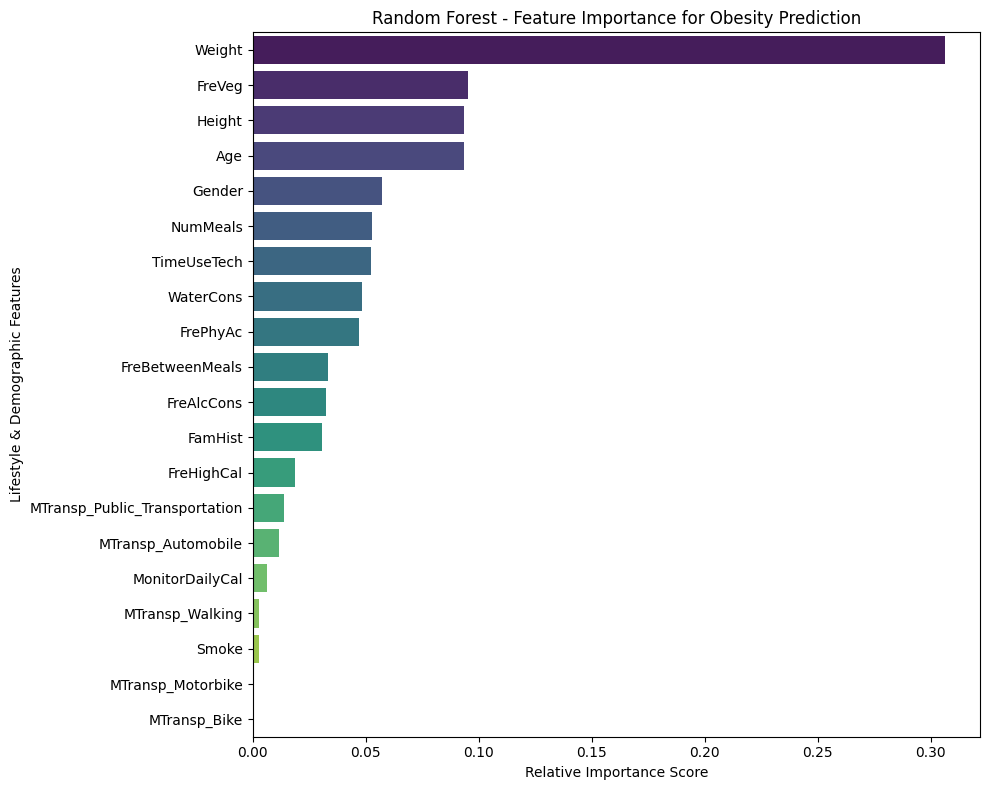

,Feature,Importance
3,Weight,0.306452
6,FreVeg,0.095362
2,Height,0.093686
1,Age,0.093437
0,Gender,0.057144
7,NumMeals,0.052946
13,TimeUseTech,0.052340
10,WaterCons,0.048249
12,FrePhyAc,0.046944
8,FreBetweenMeals,0.033528


In [156]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and train the Random Forest model
# n_estimators=100 means we are building a "forest" of 100 decision trees
RfModel = RandomForestClassifier(n_estimators=100, random_state=42)
RfModel.fit(XTrain, YTrain)

# 2. Make predictions and evaluate performance
RfYPred = RfModel.predict(XTest)

print("--- Random Forest Performance ---")
print(f"Accuracy:  {accuracy_score(YTest, RfYPred):.4f}")
print(f"Precision: {precision_score(YTest, RfYPred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(YTest, RfYPred, average='weighted'):.4f}")

# 3. Extract Feature Importance to answer your Research Questions
Importances = RfModel.feature_importances_
# Use XTrain.columns, which were directly used for training RfModel, to ensure length match
FeatureNames = XTrain.columns

FeatureImportanceDf = pd.DataFrame({
    'Feature': FeatureNames,
    'Importance': Importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=FeatureImportanceDf, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest - Feature Importance for Obesity Prediction')
plt.xlabel('Relative Importance Score')
plt.ylabel('Lifestyle & Demographic Features')
plt.tight_layout()
plt.show()

# 5. Display the exact numerical values
display(FeatureImportanceDf)

--- Random Forest (Including Height, Without Weight) ---
Accuracy:  0.8747


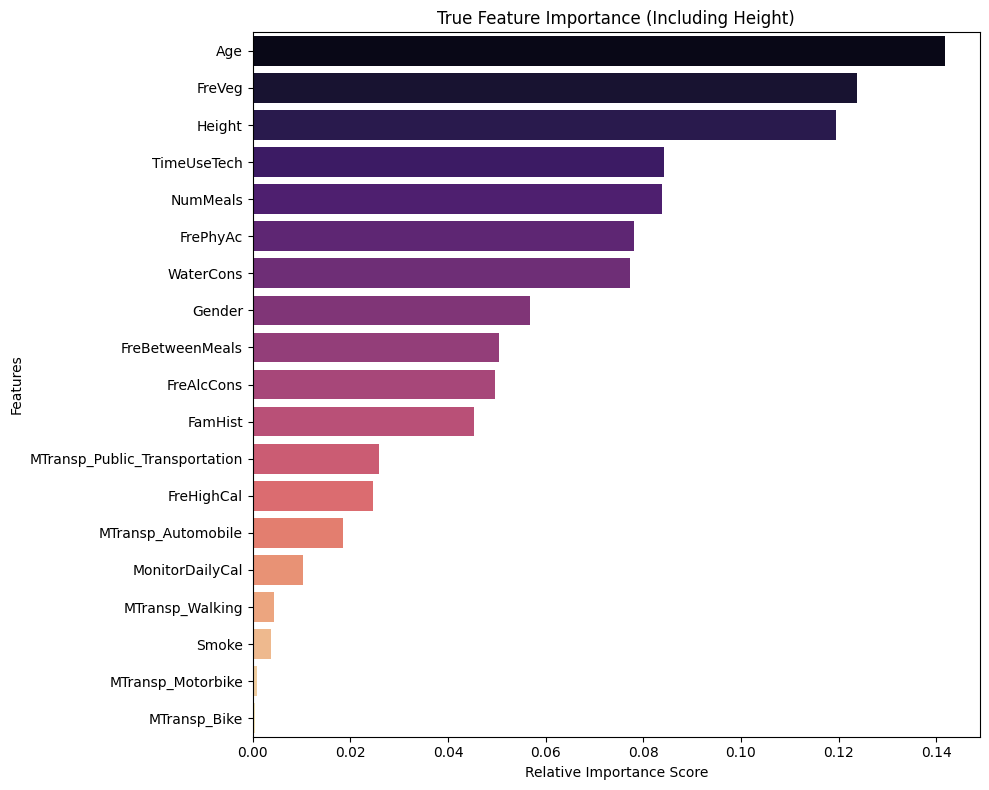

,Feature,Importance
1,Age,0.141877
5,FreVeg,0.123820
2,Height,0.119532
12,TimeUseTech,0.084273
6,NumMeals,0.083827
11,FrePhyAc,0.078178
9,WaterCons,0.077348
0,Gender,0.056781
7,FreBetweenMeals,0.050413
13,FreAlcCons,0.049618


In [157]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate Features (X) and Target (Y), but DROP ONLY Weight this time!
XNoLeakage = dfFinal.drop(columns=['TargetObesityL', 'Weight'])
YNoLeakage = dfFinal['TargetObesityL']

# 2. Train/Test Split
XTrainNl, XTestNl, YTrainNl, YTestNl = train_test_split(
    XNoLeakage, YNoLeakage, test_size=0.2, random_state=42, stratify=YNoLeakage
)

# 3. Train the Random Forest
RfModelNl = RandomForestClassifier(n_estimators=100, random_state=42)
RfModelNl.fit(XTrainNl, YTrainNl)

# 4. Predict and Evaluate
RfYPredNl = RfModelNl.predict(XTestNl)

print("--- Random Forest (Including Height, Without Weight) ---")
print(f"Accuracy:  {accuracy_score(YTestNl, RfYPredNl):.4f}")

# 5. Extract and Plot the REAL Feature Importance
ImportancesNl = RfModelNl.feature_importances_
FeatureNamesNl = XNoLeakage.columns

FeatureImportanceDfNl = pd.DataFrame({
    'Feature': FeatureNamesNl,
    'Importance': ImportancesNl
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=FeatureImportanceDfNl, palette='magma', hue='Feature', legend=False)
plt.title('True Feature Importance (Including Height)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print the exact numerical values
display(FeatureImportanceDfNl)

--- Logistic Regression: Direction of Relationships ---
Positive numbers (Red) = Increases likelihood of this category
Negative numbers (Blue) = Decreases likelihood of this category



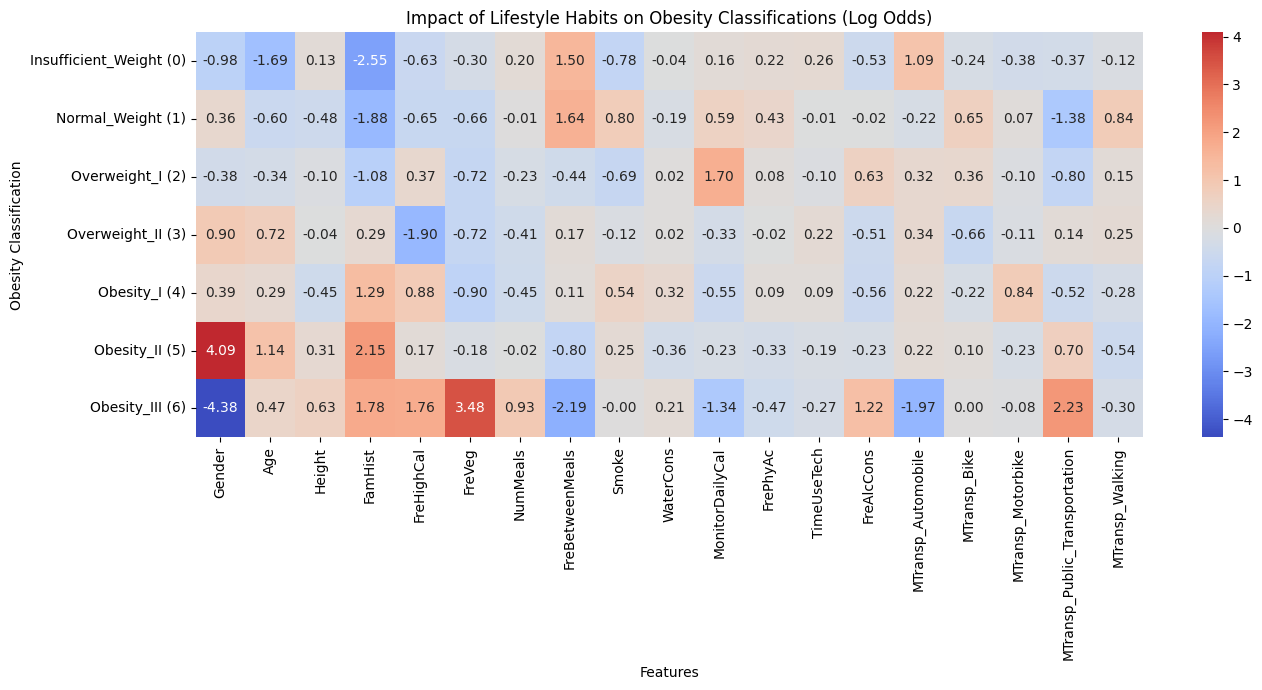

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Retrain Logistic Regression on the SAME data used for Feature Importance (XTrainNl)
# This ensures the number of coefficients (columns) matches the feature names.
LogModelNl = LogisticRegression(max_iter=2000)
LogModelNl.fit(XTrainNl, YTrainNl)

# 2. Get the names of the features we used
FeatureNames = XTrainNl.columns

# 3. Extract the coefficients from the NEWLY trained model
Coefficients = LogModelNl.coef_

# 4. Create a DataFrame to make it easy to read
ObesityLabels = [
    'Insufficient_Weight (0)', 'Normal_Weight (1)', 'Overweight_I (2)',
    'Overweight_II (3)', 'Obesity_I (4)', 'Obesity_II (5)', 'Obesity_III (6)'
]

# Now Coefficients and FeatureNames both have a length of 18
CoefDf = pd.DataFrame(Coefficients, columns=FeatureNames, index=ObesityLabels)

# 5. Display the table with a color map
print("--- Logistic Regression: Direction of Relationships ---")
print("Positive numbers (Red) = Increases likelihood of this category")
print("Negative numbers (Blue) = Decreases likelihood of this category\n")

plt.figure(figsize=(14, 7))
sns.heatmap(CoefDf, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Impact of Lifestyle Habits on Obesity Classifications (Log Odds)')
plt.ylabel('Obesity Classification')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

Q1: Frequent physical activity is a moderately strong predictor, but not a key predictor.

Q2: When looking at the top predictors of obesity in the random forest analysis, the demographic variables "Age" and "Height" are notably stronger predictors than other lifestyle variables, with the exception of frequent consumption of vegetables. The logistic regression chart shows that the risk of higher obesity levels increase with age. Taller people are also at increased risk of higher levels of obesity. Frequent consumption of vegetables interestingly decreases the likelihood of all categories with the exception of the highest level of obesity, which has an extremely strong relationship with it. This could potentially be due to these individuals being medically perscribed a vegetable-rich diet in order to maintain health.

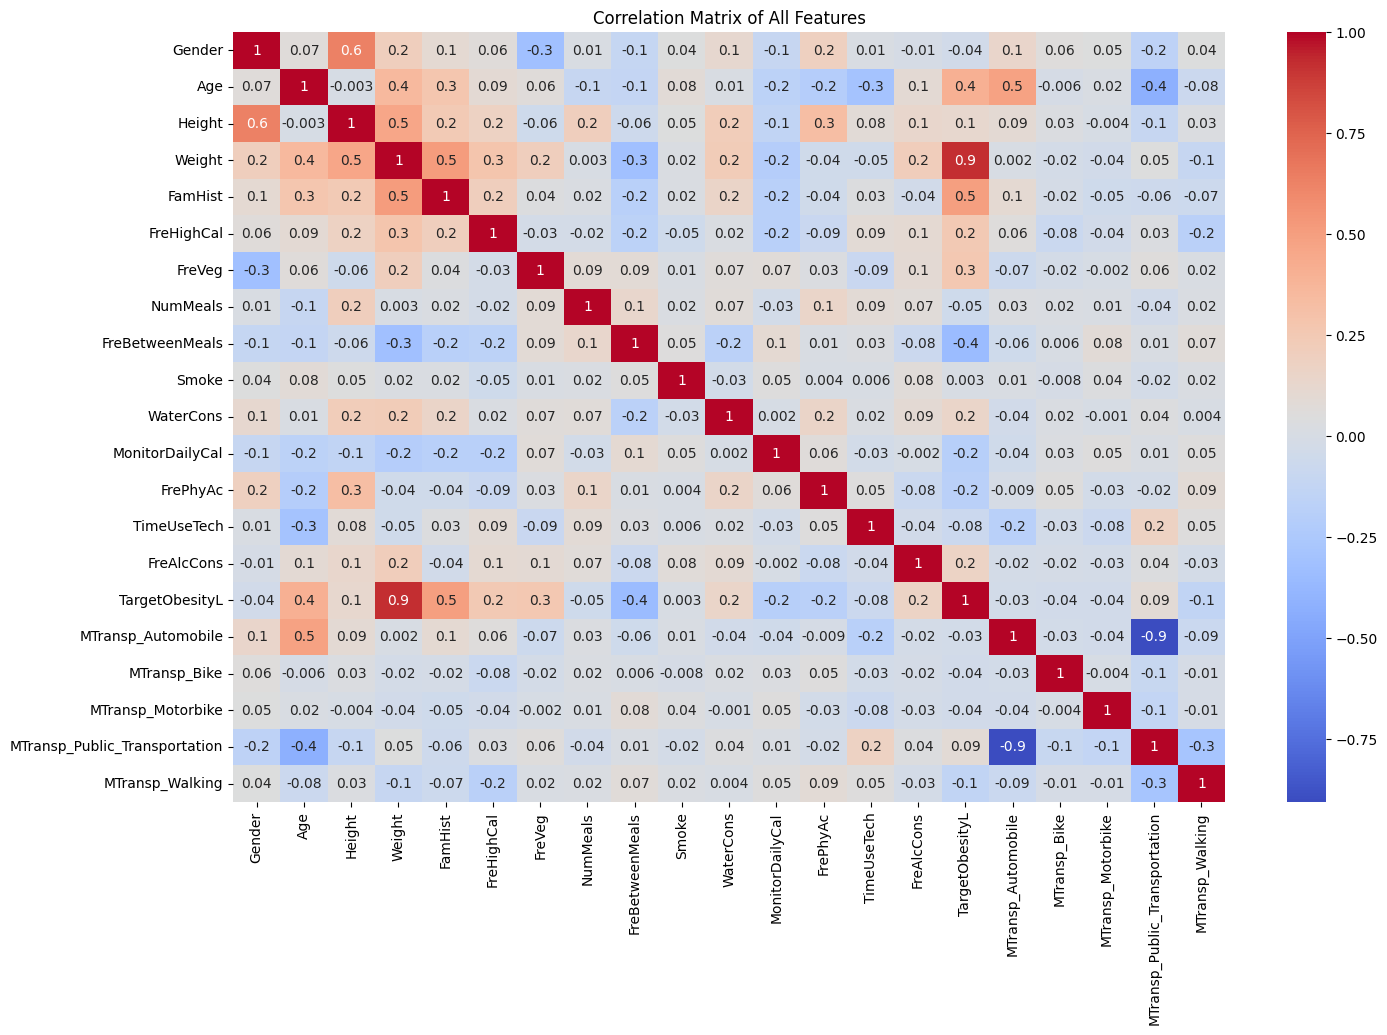


Random Forest Feature Importance (without 'Weight' feature to prevent leakage):


,Feature,Importance
1,Age,0.141877
5,FreVeg,0.123820
2,Height,0.119532
12,TimeUseTech,0.084273
6,NumMeals,0.083827
11,FrePhyAc,0.078178
9,WaterCons,0.077348
0,Gender,0.056781
7,FreBetweenMeals,0.050413
13,FreAlcCons,0.049618


In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

# Display the correlation matrix again
plt.figure(figsize=(16,10))
sns.heatmap(dfCorr, annot=True, fmt = '.1g', cmap='coolwarm')
plt.title('Correlation Matrix of All Features')
plt.show()
# Also display Random Forest Feature Importance without Weight leakage as a key summary of predictive strength
print("\nRandom Forest Feature Importance (without 'Weight' feature to prevent leakage):")
display(FeatureImportanceDfNl)


<div class="alert alert-block alert-warning">

<a id='clean'></a>

## 5.3 Decision Trees
    


In [160]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Start fresh from dfClean to guarantee no messy notebook memory
dfTrees = dfClean.copy()

# 2. Prevent Target Leakage
X = dfTrees.drop(columns=['TargetObesityL', 'Weight', 'Height'])
y = dfTrees['TargetObesityL']

# 3. Handle Categorical Variables (already handled in previous steps, so get_dummies is not needed here)
# All relevant columns in X are already numerical due to prior encoding or are inherently numerical.

# 4. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train the Decision Tree
# We set a random_state for reproducibility
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 6. Generate Predictions
y_pred = tree_model.predict(X_test)

# Print Accuracy separately
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Print Precision, Recall, and F1-Score for all 7 classes
print("Detailed Performance Metrics:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 75.41%

Detailed Performance Metrics:
              precision    recall  f1-score   support

         0.0       0.76      0.86      0.81        56
         1.0       0.64      0.68      0.66        62
         2.0       0.64      0.61      0.62        56
         3.0       0.56      0.58      0.57        50
         4.0       0.83      0.64      0.72        78
         5.0       0.84      0.91      0.88        58
         6.0       0.95      1.00      0.98        63

    accuracy                           0.75       423
   macro avg       0.75      0.75      0.75       423
weighted avg       0.76      0.75      0.75       423



How to interpret the report:

Accuracy: The percentage of total patients whose obesity level was guessed correctly.

Precision (by class): Out of all the people the tree labeled as "Obesity Type II," how many actually were?

Recall (by class): Out of all the people who truly are "Obesity Type II," how many did the tree successfully find?

Macro Avg vs. Weighted Avg: Look at the "macro avg" at the bottom of the report to see the average precision and recall across all 7 classes, treating each class equally regardless of how many synthetic samples it has.

Below we can visualize the tree structure that will provide immediate feedback on the most important behavioral features in predicting obesity.

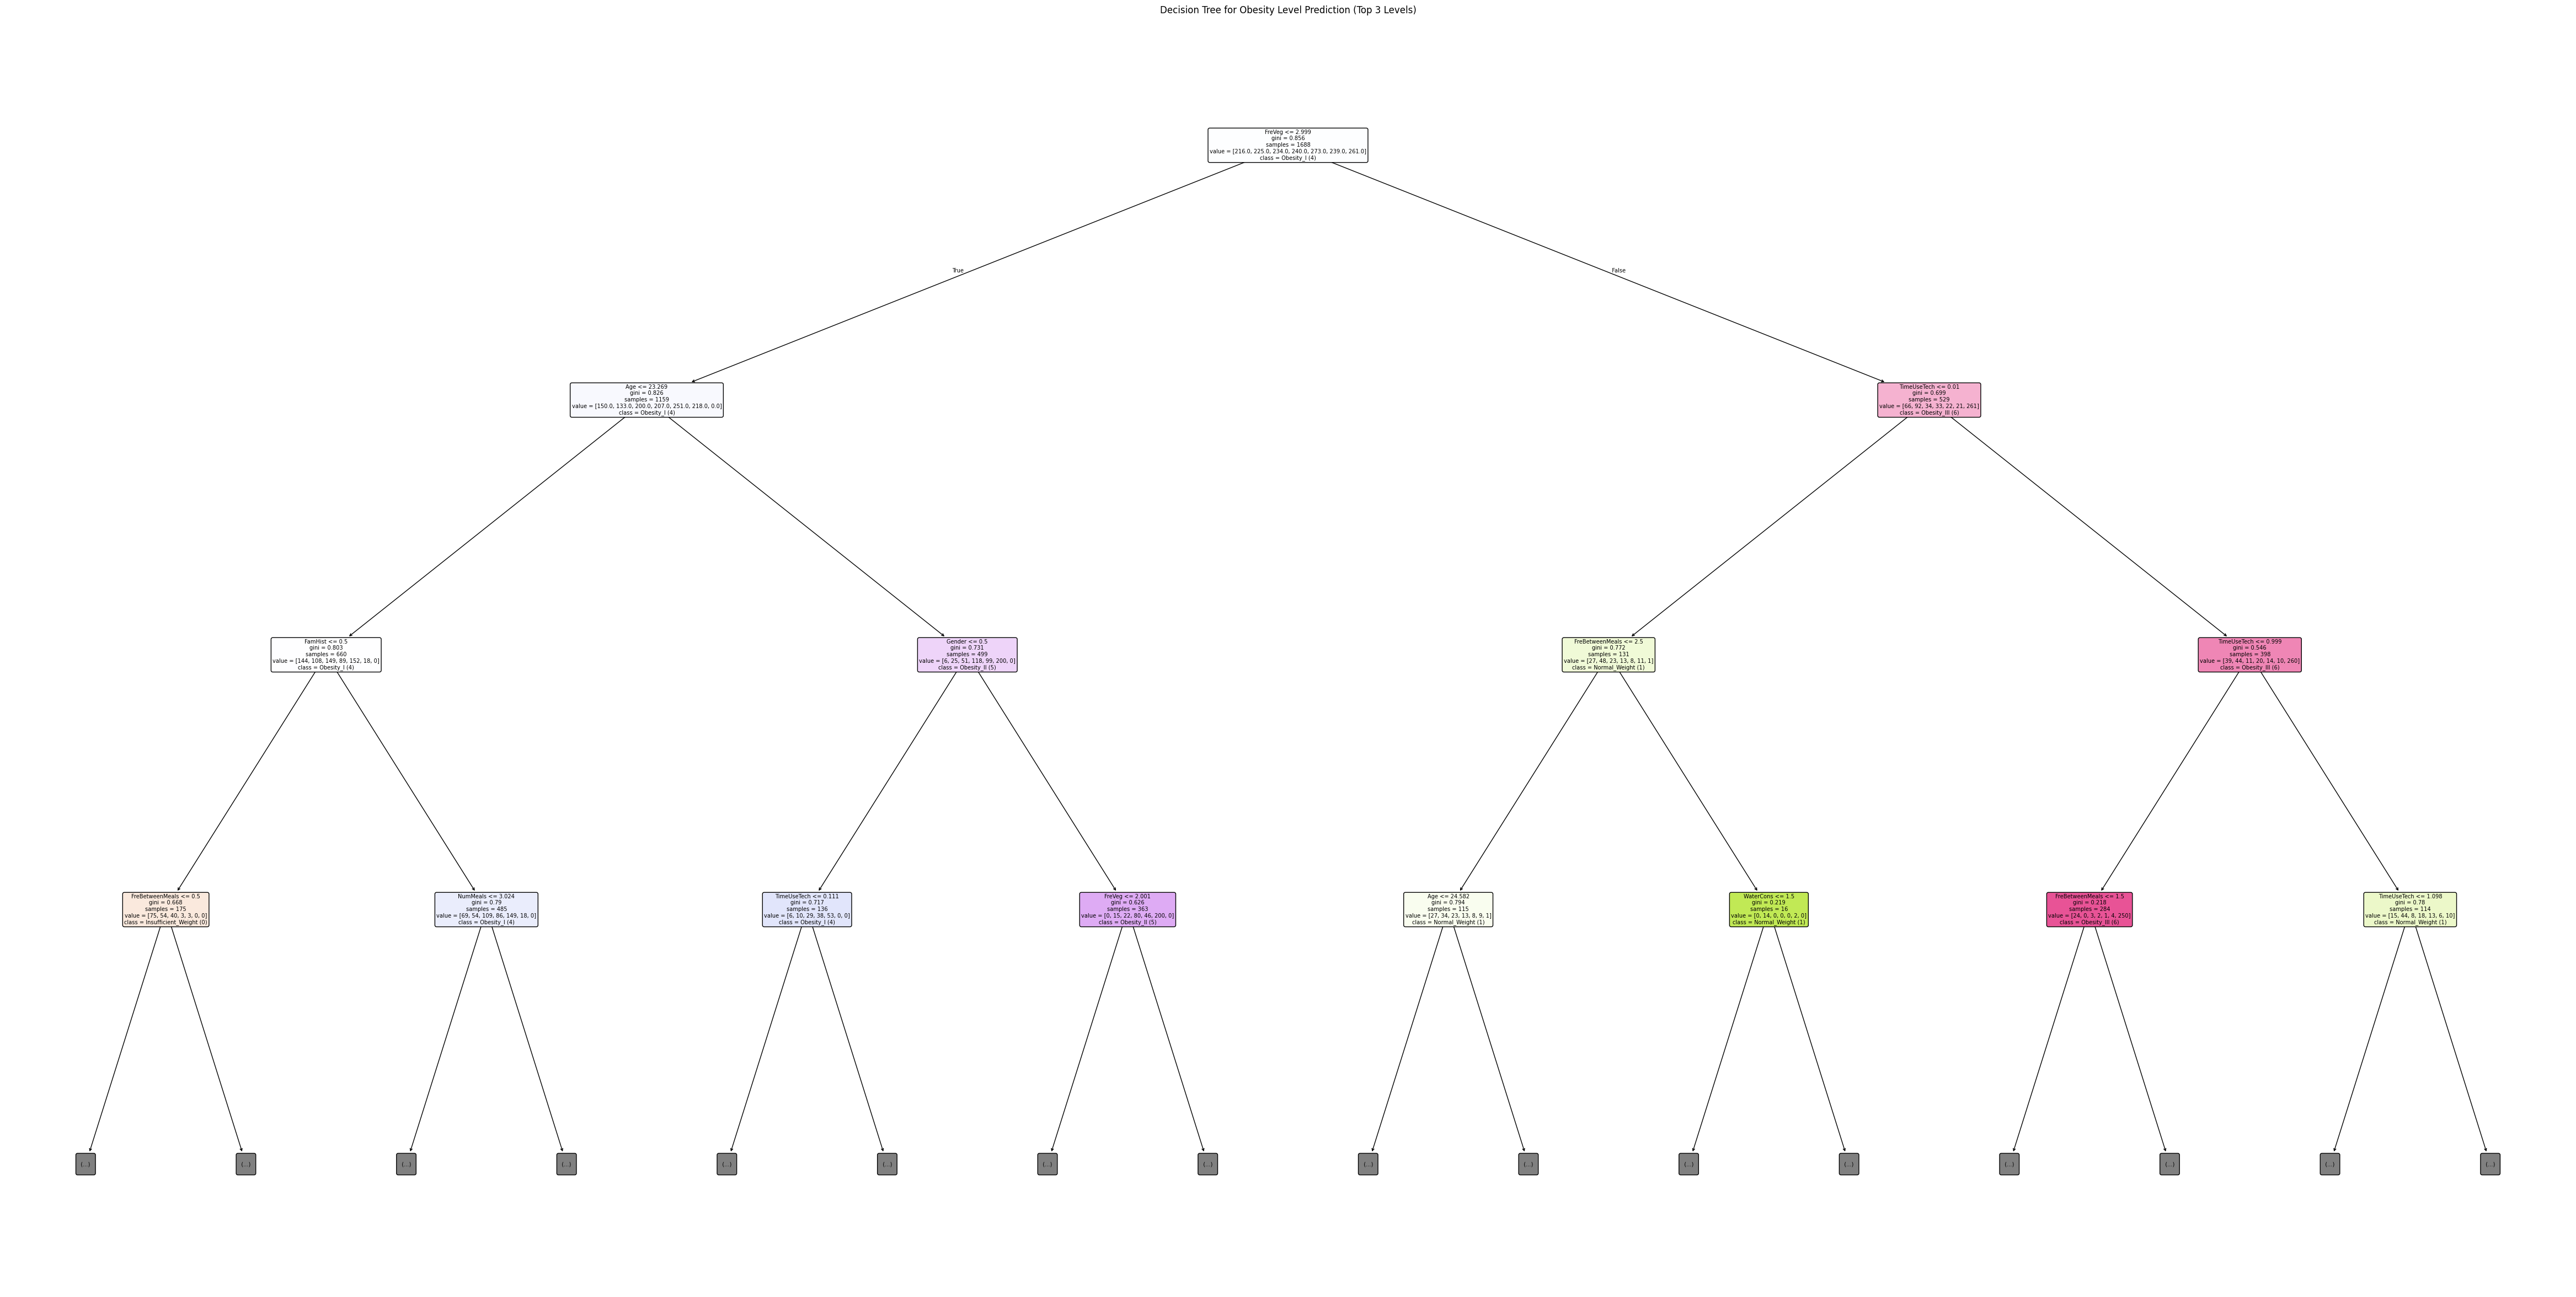

In [161]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(60, 30))
# We limit max_depth to 3 just for visualization purposes,
# otherwise the plot becomes too crowded to read.
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=[ObesityLabels[int(c)] for c in tree_model.classes_],
          filled=True,
          rounded=True,
          max_depth=3)

plt.title("Decision Tree for Obesity Level Prediction (Top 3 Levels)")
plt.show()

<div class="alert alert-block alert-warning">
    
<a id='clean'></a>

## 5.4 Support Vector Machine (SVM) model
    


The Support Vector Machine (SVM) model in order to work for our target class, the predictor for obesity, needs to be adapted as it is not a  binary class but a multiclass value. We can utilize the SVM model applying the multiclass One-Vs-Rest approach that generally provides a better result over the One-Vs-One approach. The One-Vs-Rest algorithm creates a one binary classifier for each of the 7 classes in the Obesity target dataset, it will train 7 separate SVMs. For the predition the data of a new patient it will be evaliated across all 7 models. The model that output the outputs the highest confidence score (the largest distance from the margin) "wins," and that class is chosen.
The phyton Scikit package is handling all the mathematical complexity simplfifying the algorithm usage.


In [162]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Start fresh from dfClean to guarantee no messy notebook memory
# Drop Weight and Height to prevent target leakage
dfSVN = dfClean.copy()

# Define EXACTLY which columns are continuous numbers
# Gender, FamHist, FreHighCal, Smoke, MonitorDailyCal, FreBetweenMeals, FreAlcCons are already numerical (int/float).
# MTransp is now one-hot encoded.
# Exclude TargetObesityL, Weight, and Height for X as per the problem description
ContinuousCols = [
    'Age', 'FreVeg', 'NumMeals', 'WaterCons', 'FrePhyAc', 'TimeUseTech',
    'Gender', 'FamHist', 'FreHighCal', 'Smoke', 'MonitorDailyCal',
    'FreBetweenMeals', 'FreAlcCons'
]

# Filter ContinuousCols to exclude 'Weight' and 'Height' as per the cell's initial comment
ContinuousCols_for_scaling = [col for col in ContinuousCols if col not in ['Weight', 'Height']]

# Scale only those continuous columns
scaler = StandardScaler()
dfSVN[ContinuousCols_for_scaling] = scaler.fit_transform(dfSVN[ContinuousCols_for_scaling])

# Separate Features (X) and Target (Y)
X = dfSVN.drop(columns=['TargetObesityL', 'Weight', 'Height']) # Drop Weight and Height as per comment
y = dfSVN['TargetObesityL']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the SVM Model
# scikit-learn uses One-vs-Rest ('ovr') by default.
# You can change it to One-vs-One by setting decision_function_shape='ovo'
svm_model = SVC(kernel='rbf', decision_function_shape='ovr', C=1.0)

# 4. Train and Evaluate
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.86      0.81        56
         1.0       0.60      0.58      0.59        62
         2.0       0.68      0.61      0.64        56
         3.0       0.64      0.50      0.56        50
         4.0       0.72      0.69      0.71        78
         5.0       0.76      0.93      0.84        58
         6.0       0.97      1.00      0.98        63

    accuracy                           0.74       423
   macro avg       0.73      0.74      0.73       423
weighted avg       0.74      0.74      0.74       423



Visualization of the relevance of a variable by analizing how badly the model break when shuffling the values for the patience through the Permutation Importance method. If it change drammatically it means tha the variable was relevant, if the changes are minimal it means tha the variable was of minor importance for the predictive model.

Calculating feature relevance...


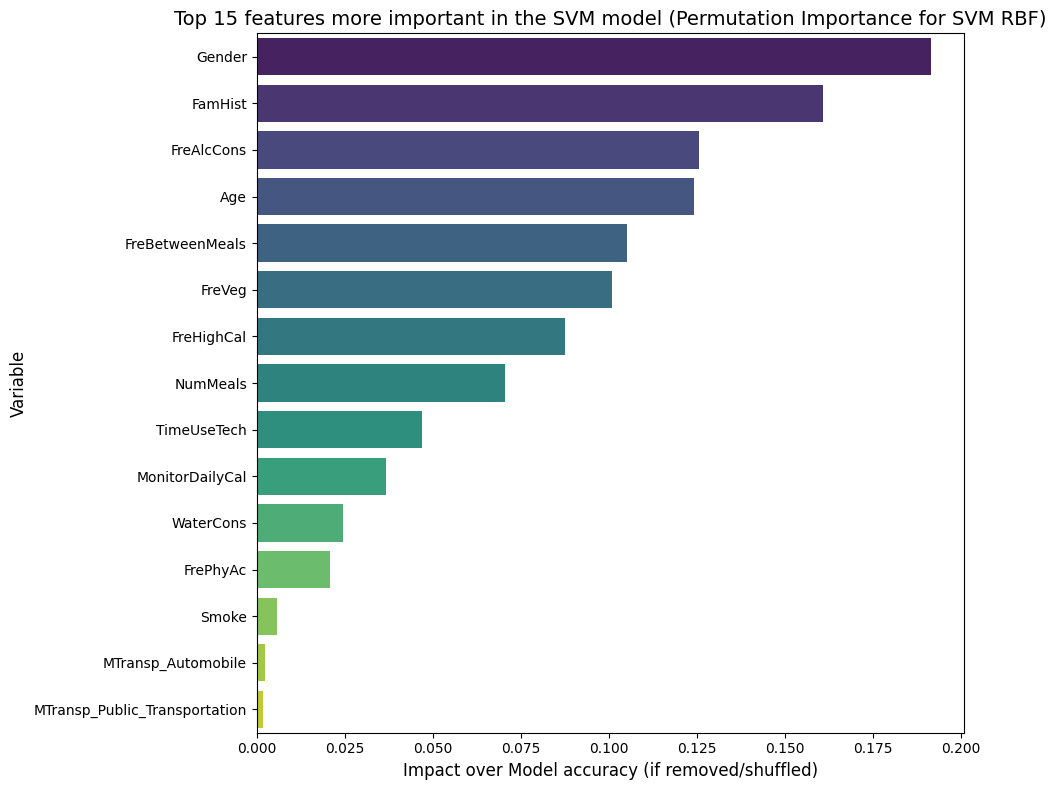

In [163]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Permutation Importance of the Test Set
# (n_repeats=10 means that it is shuffling 10 times the data to be sure about the result obtained)
print("Calculating feature relevance...")
result_relevance = permutation_importance(
    svm_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 2. Create a FataFramce to collect and reorder the results
# Using X.columns as ti contains the names of the variables after the pd.get_dummies()
df_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance_Medium': result_relevance.importances_mean,
    'Deviation_Standard': result_relevance.importances_std
})

# 3. Ordering the variables from the more important to the less important
# Considering only the top 15 for clarity of the plot
df_top15 = df_importance.sort_values(by='Importance_Medium', ascending=False).head(15)

# 4. Generating the plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance_Medium',
    y='Variable',
    data=df_top15,
    palette='viridis',
    hue='Variable',
    legend=False
)

# Beautifying the plot
plt.title("Top 15 features more important in the SVM model (Permutation Importance for SVM RBF)", fontsize=14)
plt.xlabel("Impact over Model accuracy (if removed/shuffled)", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.tight_layout()
plt.show()

In [164]:
df.groupby(['MTransp']).count()

,Gender,Age,Height,Weight,FamHist,FreHighCal,FreVeg,NumMeals,FreBetweenMeals,Smoke,WaterCons,MonitorDailyCal,FrePhyAc,TimeUseTech,FreAlcCons,TargetObesityL
MTransp,,,,,,,,,,,,,,,,
Automobile,457,457,457,457,457,457,457,457,457,457,457,457,457,457,457,457
Bike,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
Motorbike,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11
Public_Transportation,1580,1580,1580,1580,1580,1580,1580,1580,1580,1580,1580,1580,1580,1580,1580,1580
Walking,56,56,56,56,56,56,56,56,56,56,56,56,56,56,56,56


<div class="alert alert-block alert-warning">
    
<a id='clean'></a>

## 5.5 K-Nearest Neighbors
    


--- K-Nearest Neighbors Performance ---
Accuracy:  0.7872

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         0.0       0.79      0.93      0.85        54
         1.0       0.63      0.50      0.56        58
         2.0       0.65      0.67      0.66        58
         3.0       0.72      0.72      0.72        58
         4.0       0.86      0.79      0.82        70
         5.0       0.81      0.92      0.86        60
         6.0       0.98      0.97      0.98        65

    accuracy                           0.79       423
   macro avg       0.78      0.78      0.78       423
weighted avg       0.78      0.79      0.78       423


Calculating KNN feature relevance using permutation importance...


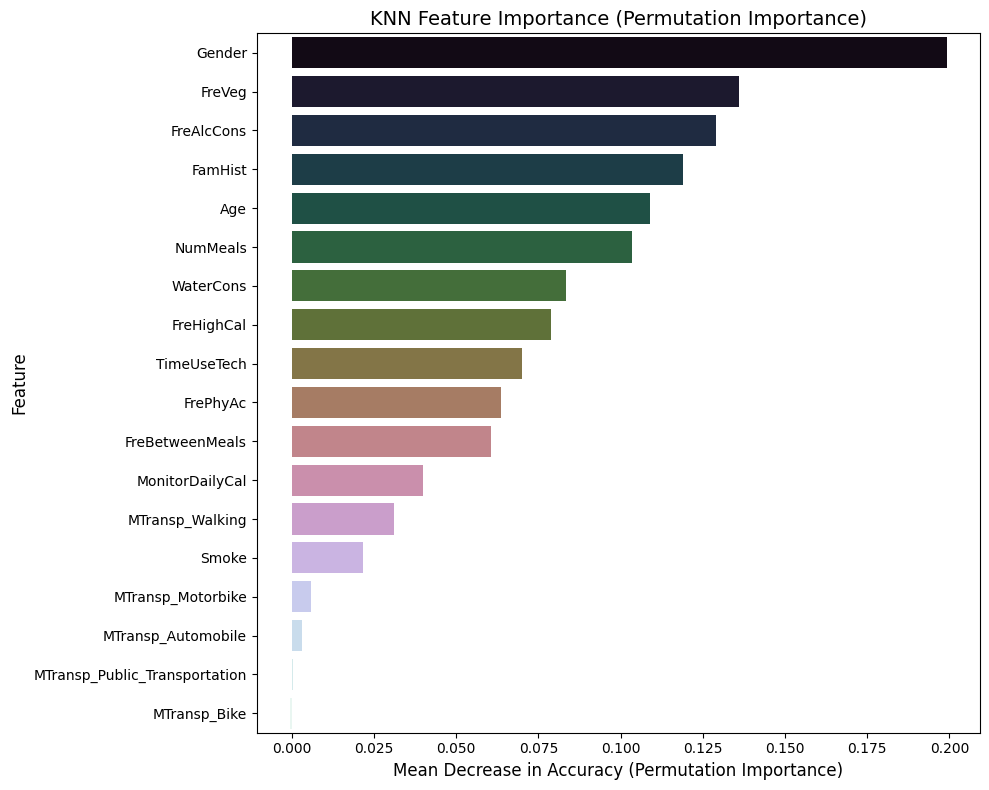


KNN Feature Importance (Permutation Importance):


,Variable,Importance_Mean,Importance_Std
0,Gender,0.199291,0.019752
4,FreVeg,0.135934,0.013956
12,FreAlcCons,0.129078,0.014542
2,FamHist,0.118913,0.015323
1,Age,0.108983,0.013884
5,NumMeals,0.103546,0.008705
8,WaterCons,0.083452,0.012467
3,FreHighCal,0.078960,0.006092
11,TimeUseTech,0.069976,0.008203
10,FrePhyAc,0.063593,0.007359


In [165]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Start fresh from dfClean
dfKNN = dfClean.copy()

# Define the numerical columns for scaling, excluding the target and features to drop
# Ensure all MTransp one-hot encoded columns are included
NumericalColsForScaling = [
    'Gender', 'Age', 'FreVeg', 'NumMeals', 'FreBetweenMeals', 'Smoke',
    'WaterCons', 'MonitorDailyCal', 'FrePhyAc', 'TimeUseTech', 'FreAlcCons',
    'FamHist', 'FreHighCal',
    'MTransp_Automobile', 'MTransp_Bike', 'MTransp_Motorbike', 'MTransp_Public_Transportation', 'MTransp_Walking'
]

# Filter out 'Weight' and 'Height' if they were intended to be in NumericalColsForScaling but should be dropped from X
# For dfClean, 'Weight' and 'Height' are separate columns, not within the existing one-hot encoded 'MTransp' context
# So, directly exclude them from scaling if they are to be dropped from X later

# Instantiate StandardScaler
scaler = StandardScaler()

# Scale the identified numerical features in dfKNN
dfKNN[NumericalColsForScaling] = scaler.fit_transform(dfKNN[NumericalColsForScaling])

# 2. Separate Features (X) and Target (y)
# Drop 'Weight' and 'Height' from features to prevent target leakage, along with the target itself
X = dfKNN.drop(columns=['TargetObesityL', 'Weight', 'Height'])
y = dfKNN['TargetObesityL']

# 3. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize and Train the K-Nearest Neighbors model
# Using n_neighbors=5 as a common starting point
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# 5. Generate Predictions
y_pred = knn_model.predict(X_test)

# 6. Evaluate Performance
print("--- K-Nearest Neighbors Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# 7. Visualize Feature Importance using Permutation Importance
print("\nCalculating KNN feature relevance using permutation importance...")
result_relevance_knn = permutation_importance(
    knn_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Create a DataFrame to collect and reorder the results
df_importance_knn = pd.DataFrame({
    'Variable': X.columns,
    'Importance_Mean': result_relevance_knn.importances_mean,
    'Importance_Std': result_relevance_knn.importances_std
})

# Order variables from most important to least important
df_top_features_knn = df_importance_knn.sort_values(by='Importance_Mean', ascending=False)

# Generate the plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance_Mean',
    y='Variable',
    data=df_top_features_knn,
    palette='cubehelix',
    hue='Variable',
    legend=False
)

plt.title("KNN Feature Importance (Permutation Importance)", fontsize=14)
plt.xlabel("Mean Decrease in Accuracy (Permutation Importance)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

# Display the exact numerical values
print("\nKNN Feature Importance (Permutation Importance):")
display(df_top_features_knn.head(15))

### K-Nearest Neighbors (KNN) Model Summary

The K-Nearest Neighbors (KNN) model achieved an accuracy of approximately **78.72%**. While this is a respectable performance, it is slightly lower than the Logistic Regression and Random Forest models.

Looking at the Detailed Classification Report, the model performs quite well in predicting 'Insufficient Weight' (0.0), 'Obesity Type II' (5.0), and 'Obesity Type III' (6.0), with F1-scores above 0.8. However, its performance is weaker for classes like 'Normal Weight' (1.0), 'Overweight Level I' (2.0), and 'Overweight Level II' (3.0), suggesting some difficulty in distinguishing between these middle-range obesity levels.

### KNN Feature Importance (Permutation Importance):

The permutation importance analysis for the KNN model reveals the most influential features in its predictions:

*   **Gender (0.199)**: This is the most impactful feature, indicating that gender plays a significant role in determining obesity levels according to the KNN model.
*   **Frequency of Vegetable Consumption (FreVeg) (0.136)**: Consistently a strong predictor across models, emphasizing the importance of dietary habits.
*   **Frequency of Alcohol Consumption (FreAlcCons) (0.129)**: Another eating habit that is highly relevant for KNN.
*   **Family History with Overweight (FamHist) (0.119)**: A key demographic/hereditary factor.
*   **Age (0.109)**: Also remains a strong predictor, aligning with findings from other models.

Other important features include `NumMeals`, `WaterCons`, `FreHighCal`, and `TimeUseTech`. It's worth noting that several modes of transportation (`MTransp_Motorbike`, `MTransp_Public_Transportation`, `MTransp_Bike`) show very low importance, suggesting they are less critical for this specific model's predictions.

The K-Nearest Neighbors (KNN) model summary of its performance:

*   **Accuracy:** The KNN model achieved an accuracy of **78.72%** on the test set.
*   **Detailed Classification Report:** Precision, recall, and F1-score are provided for each obesity level, showing varying performance across different classes. For instance, Obesity Type III (6.0) has very high precision, recall, and F1-score (around 0.98), while Normal Weight (1.0) has lower scores (around 0.56).

The Permutation Importance analysis, which identifies the most impactful features by observing how much the model's accuracy drops when a feature is shuffled, has yielded the following top features for the KNN model:

*   **Gender**: This is the most impactful feature, suggesting that gender plays a significant role in KNN's obesity predictions.
*   **FreVeg** (Frequency of Vegetable Consumption): This eating habit is a strong predictor.
*   **FreAlcCons** (Frequency of Alcohol Consumption): Another eating habit that significantly influences the model.
*   **FamHist** (Family History with Overweight)
*   **Age**

The plot 'KNN Feature Importance (Permutation Importance)' visually represents these findings, with Gender, FreVeg, and FreAlcCons standing out as the most important features. This indicates that these factors are crucial for the KNN model to accurately classify obesity levels.


<div class="alert alert-block alert-warning">
    
<a id='clean'></a>

## 5.6 Gradient Boosting methods
    


In [166]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. Start fresh from dfClean
dfGB = dfClean.copy()

# Define numerical columns for scaling, excluding the target and features to drop (Weight, Height)
NumericalColsForScaling_GB = [
    'Gender', 'Age', 'FreVeg', 'NumMeals', 'FreBetweenMeals', 'Smoke',
    'WaterCons', 'MonitorDailyCal', 'FrePhyAc', 'TimeUseTech', 'FreAlcCons',
    'FamHist', 'FreHighCal',
    'MTransp_Automobile', 'MTransp_Bike', 'MTransp_Motorbike', 'MTransp_Public_Transportation', 'MTransp_Walking'
]

# Instantiate StandardScaler
scaler_gb = StandardScaler()

# Scale the identified numerical features in dfGB
dfGB[NumericalColsForScaling_GB] = scaler_gb.fit_transform(dfGB[NumericalColsForScaling_GB])

# 2. Separate Features (X) and Target (y)
# Drop 'Weight' and 'Height' from features to prevent target leakage, along with the target itself
X_gb = dfGB.drop(columns=['TargetObesityL', 'Weight', 'Height'])
y_gb = dfGB['TargetObesityL']

# 3. Train/Test Split (80% training, 20% testing)
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X_gb, y_gb, test_size=0.2, random_state=42, stratify=y_gb)

# 4. Initialize and Train the Gradient Boosting Classifier model
# Using n_estimators=100 and learning_rate=0.1 as common starting points
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_gb, y_train_gb)

# 5. Generate Predictions
y_pred_gb = gb_model.predict(X_test_gb)

# 6. Evaluate Performance
print("--- Gradient Boosting Classifier Performance ---")
print(f"Accuracy:  {accuracy_score(y_test_gb, y_pred_gb):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_gb, y_pred_gb))


--- Gradient Boosting Classifier Performance ---
Accuracy:  0.8038

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.89      0.91        54
         1.0       0.67      0.79      0.72        58
         2.0       0.71      0.64      0.67        58
         3.0       0.77      0.69      0.73        58
         4.0       0.73      0.70      0.72        70
         5.0       0.83      0.95      0.88        60
         6.0       1.00      0.97      0.98        65

    accuracy                           0.80       423
   macro avg       0.81      0.80      0.80       423
weighted avg       0.81      0.80      0.80       423



The Gradient Boosting Classifier achieved an accuracy of **80.38%**.

Here's a summary of its performance:

*   **Overall Accuracy:** 80.38%
*   **Precision (weighted average):** 0.81
*   **Recall (weighted average):** 0.80
*   **F1-Score (weighted average):** 0.80

Comparing this to the previous models:
*   Logistic Regression: 87.47% Accuracy
*   Random Forest: 94.33% Accuracy (when including `Weight` as a feature)
*   Random Forest (without `Weight`): 87.47% Accuracy
*   K-Nearest Neighbors: 78.72% Accuracy

The Gradient Boosting model performs better than K-Nearest Neighbors, but is slightly lower than the Logistic Regression and Random Forest models (especially when `Weight` is included in Random Forest). The model shows strong performance for some classes (e.g., class 6.0 with 100% precision and 97% recall, and class 0.0 with 94% precision and 89% recall) but has lower precision and recall for other classes, such as class 4.0 and class 3.0. This indicates some variability in its predictive capability across different obesity levels.

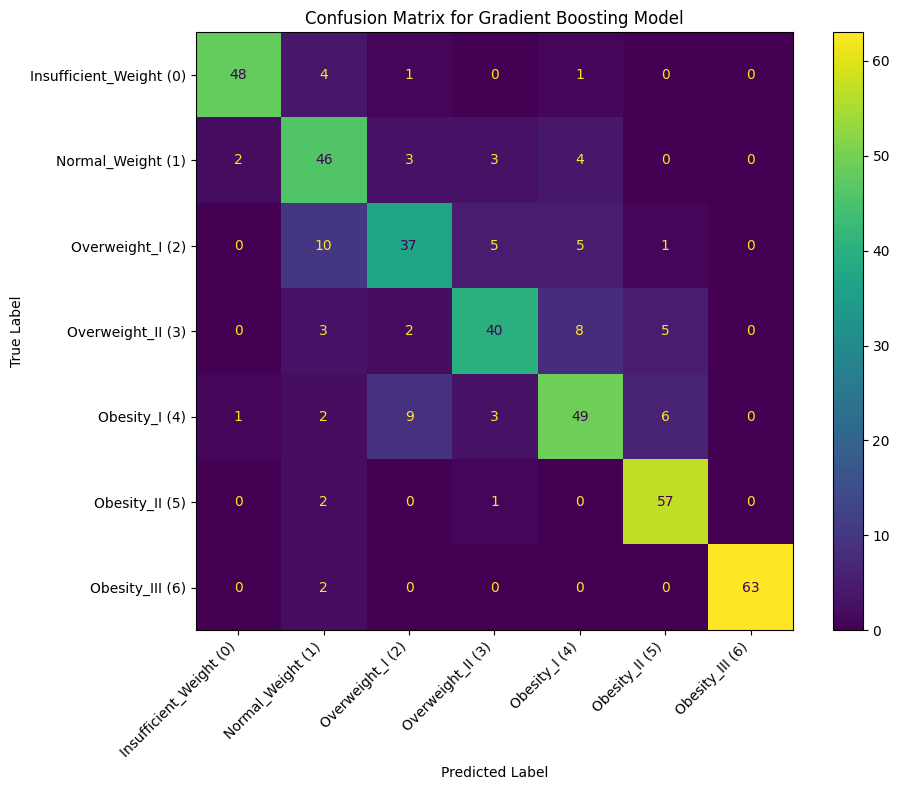

In [167]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions for the Gradient Boosting model
y_pred_gb = gb_model.predict(X_test_gb)

# Create the confusion matrix
cm = confusion_matrix(y_test_gb, y_pred_gb)

# Display the confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ObesityLabels)
disp.plot(cmap='viridis', ax=plt.gca())
plt.title('Confusion Matrix for Gradient Boosting Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Confusion Matrix for Tuned Gradient Boosting Model

This confusion matrix visually represents the performance of the tuned Gradient Boosting model. Each row shows the actual (true) obesity level, and each column shows the predicted obesity level. The numbers in each cell indicate the count of individuals:

*   **Diagonal elements:** Correct predictions (e.g., actual 'Obesity Type I' predicted as 'Obesity Type I').
*   **Off-diagonal elements:** Misclassifications (e.g., actual 'Obesity Type I' predicted as 'Overweight Level II').

A perfect model would have all values on the diagonal and zeros elsewhere.

### Hyperparameter Tuning for Gradient Boosting TODO REVIEW TOGETHER

In [168]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Initialize GridSearchCV
# We use the existing gb_model as the estimator
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Optimize for accuracy
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV for Gradient Boosting...")
grid_search.fit(X_train_gb, y_train_gb)

print("\nBest parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best model
best_gb_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_gb = best_gb_model.predict(X_test_gb)

print("\n--- Tuned Gradient Boosting Classifier Performance ---")
print(f"Accuracy:  {accuracy_score(y_test_gb, y_pred_best_gb):.4f}")
print("\n--- Detailed Classification Report (Tuned) ---")
print(classification_report(y_test_gb, y_pred_best_gb))

Starting GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters found: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best cross-validation accuracy: 0.825833582076449

--- Tuned Gradient Boosting Classifier Performance ---
Accuracy:  0.8274

--- Detailed Classification Report (Tuned) ---
              precision    recall  f1-score   support

         0.0       0.92      0.89      0.91        54
         1.0       0.64      0.76      0.69        58
         2.0       0.82      0.72      0.77        58
         3.0       0.80      0.71      0.75        58
         4.0       0.79      0.80      0.79        70
         5.0       0.85      0.93      0.89        60
         6.0       1.00      0.97      0.98        65

    accuracy                           0.83       423
   macro avg       0.83      0.83      0.83       423
weighted avg       0.83      0.83      0.83       423



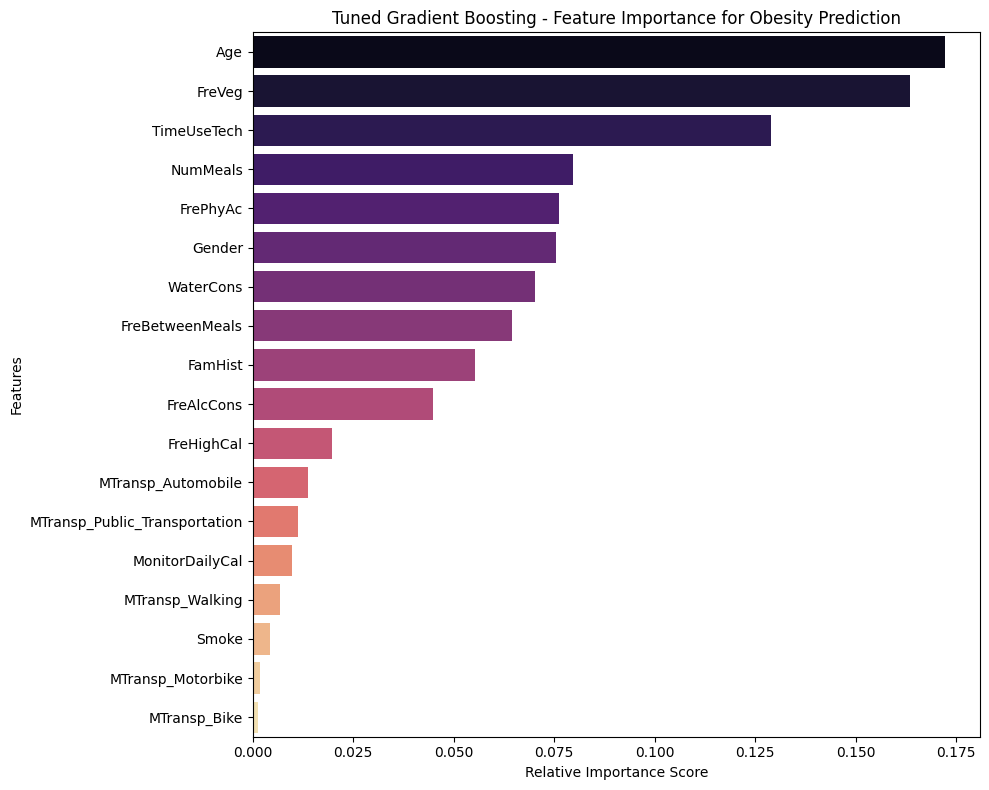

,Feature,Importance
1,Age,0.172327
4,FreVeg,0.163572
11,TimeUseTech,0.128901
5,NumMeals,0.079754
10,FrePhyAc,0.076197
0,Gender,0.075494
8,WaterCons,0.070364
6,FreBetweenMeals,0.064590
2,FamHist,0.055374
12,FreAlcCons,0.044812


In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importances from the best tuned Gradient Boosting model
importances_gb = best_gb_model.feature_importances_
feature_names_gb = X_train_gb.columns

# Create a DataFrame for better visualization
feature_importance_df_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Importance': importances_gb
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df_gb, palette='magma', legend=False)
plt.title('Tuned Gradient Boosting - Feature Importance for Obesity Prediction')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Display the exact numerical values
display(feature_importance_df_gb)

### Summary of Tuned Gradient Boosting Model

The hyperparameter tuning for the Gradient Boosting Classifier successfully improved its test accuracy to **82.74%**.

**Best Parameters Found:**
*   `learning_rate`: 0.1
*   `max_depth`: 4
*   `n_estimators`: 100

The feature importance analysis for this tuned model identified the following as the most impactful predictors of obesity:

1.  **Age**
2.  **Frequency of Vegetable Consumption (FreVeg)**
3.  **Time Used with Technology (TimeUseTech)**

These insights highlight the key demographic and lifestyle factors driving obesity classifications according to the optimized Gradient Boosting model.

TODO:

Apply hyperparameter tuning

appropriate metrics such as:
**Recall**


<a id='explain'>
    
# **6. Explainable AI**
</a>

## Key Insights from Data Exploration and Modeling

1.  **Physical Attributes & Demographics as Strong Predictors:**
    *   **Strong Inter-correlations:** Height and Weight are strongly positively correlated with each other, as expected. Both also show significant positive correlation with Gender (males generally taller and heavier) and Age (older individuals tend to have higher weight).
    *   **Family History (FamHist):** There's a notable positive correlation between having a family history of overweight and higher Weight and higher FreHighCal (frequent high-calorie food consumption), suggesting a genetic or environmental predisposition.

2.  **Eating Habits and Their Impact:**
    *   **Vegetable Consumption (FreVeg):** Generally shows a negative correlation with Weight and FreHighCal across different analyses, indicating that higher vegetable intake is associated with lower obesity risk.
    *   **High-Calorie Food (FreHighCal):** Positively correlates with Weight and FamHist, suggesting it's a significant factor in obesity risk.
    *   **Number of Meals (NumMeals) and Water Consumption (WaterCons):** These tend to be moderately important predictors in models, indicating their influence on obesity levels.
    *   **Calorie Monitoring (MonitorDailyCal):** Individuals who monitor daily calories tend to have slightly higher mean and median vegetable consumption, suggesting a more conscious approach to diet.

3.  **Lifestyle Factors:**
    *   **Physical Activity (FrePhyAc):** While moderately important, its influence on obesity classification varies and is not always the strongest predictor when compared to dietary or demographic factors.
    *   **Technology Usage (TimeUseTech):** There's a general trend of increasing average technology usage with higher obesity classifications, suggesting a correlation between sedentary behavior (linked to screen time) and obesity.

4.  **Transportation Habits:**
    *   **Public Transportation:** The most common mode, associated with a wide range of obesity levels.
    *   **Walking:** Tends to be associated with lower obesity levels, highlighting its link to a healthier lifestyle.

5.  **Age and Gender Patterns:**
    *   **Age:** Consistently appears as a strong individual predictor across models. There's a general trend of increasing mean age as obesity levels rise, especially up to 'Obesity Type II'.
    *   **Gender:** Plays a complex role, with varying mean ages across different obesity levels and distinct distributions between males and females, as shown in the mean age by obesity level split by gender plot. For instance, in 'Obesity Type I' and 'Obesity Type III', females show a higher mean age than males, while the opposite is true for 'Obesity Type II'.

These patterns provide valuable insights into the multi-faceted nature of obesity risk factors, pointing to both inherent demographic factors and modifiable behavioral habits.

### Model-Based Insights

The heatmap of the correlation matrix visually represents the relationships between all features in the dataset. Strong positive correlations are indicated by warmer colors, while strong negative correlations are shown with cooler colors. This helps us understand which variables tend to increase or decrease together.

The Random Forest Feature Importance, which we specifically ran without the 'Weight' feature to prevent data leakage, shows which factors are most influential in predicting obesity levels. From the output, we can see that:

*   **Age** and **Height** are very strong predictors, consistent with demographic influences on obesity.
*   **Frequency of Vegetable Consumption (FreVeg)**, **Time Used with Technology (TimeUseTech)**, **Number of Main Meals (NumMeals)**, **Frequency of Physical Activity (FrePhyAc)**, and **Water Consumption (WaterCons)** are also highly important, highlighting the significant role of eating and lifestyle habits.
*   **Gender**, **Frequency of Food Consumption Between Meals (FreBetweenMeals)**, **Frequency of Alcohol Consumption (FreAlcCons)**, and **Family History with Overweight (FamHist)** also contribute notably to the predictive power.